<a href="https://colab.research.google.com/github/andrewcxjin/computer-vision-project/blob/lindsaynewmodelbranch/uav_human_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Robust Human Detection in UAV Imagery
## HIT-UAV Infrared Thermal Dataset - Baseline vs Augmented Comparison

---

### Project Overview

This notebook implements and compares multiple approaches to human detection in UAV (drone) thermal imagery,
with a focus on **robustness to adverse environmental conditions** like snow, smoke, and fire.

### Experiment Design

| Model | Training Data | Purpose |
|-------|--------------|--------|
| **Model A (Baseline)** | Clean images only | Establish baseline performance |
| **Model B (Augmented)** | 50% clean + 50% perturbed | Test robustness improvement |

### Evaluation Strategy
- Both models evaluated on **clean test set** (standard performance)
- Both models evaluated on **perturbed test set** (robustness under adverse conditions)
- Compare F1 score drop between clean → perturbed to measure robustness

### Dataset
**HIT-UAV Dataset** from Kaggle - thermal infrared UAV imagery containing:
- 5 classes: Person, Car, Bicycle, OtherVehicle, DontCare
- High-altitude drone captures
- Infrared thermal imaging

---

## Cell 1: Environment Setup

In [ ]:
# =============================================================================
# CELL 1: ENVIRONMENT SETUP
# =============================================================================

import subprocess
import sys
import os

def install_packages():
    """Install required packages."""
    packages = [
        'torch', 'torchvision', 'albumentations>=1.3.0', 'pycocotools',
        'opencv-python-headless', 'matplotlib', 'numpy', 'Pillow',
        'tqdm', 'scipy', 'kaggle',
        'scikit-learn', 'scikit-image', 'joblib'  # For HOG+SVM classical model
    ]
    for pkg in packages:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
    print("Packages installed")

install_packages()

# No Google Drive mounting; data is stored locally under Config.DATA_ROOT when running in Colab or locally.

Packages installed


## Cell 2: Imports and Configuration

In [ ]:
# =============================================================================
# CELL 2: IMPORTS AND CONFIGURATION
# =============================================================================

import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import json
import os
import shutil
import zipfile
import copy
from pathlib import Path
from tqdm.auto import tqdm
import random
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Configuration
class Config:
    # Paths
    IN_COLAB = bool(os.environ.get('COLAB_GPU') or os.environ.get('KAGGLE_KERNEL_RUN_TYPE') or 'google.colab' in str(getattr(__import__('sys'), 'modules', {})))
    BASE_DIR = Path('/content') if IN_COLAB else Path('.')
    DATA_ROOT = BASE_DIR / 'hit-uav'
    CHECKPOINT_DIR = BASE_DIR / 'checkpoints'
    OUTPUT_DIR = BASE_DIR / 'outputs'

    # Image settings
    IMG_SIZE = 512

    # Training settings
    BATCH_SIZE = 4
    NUM_EPOCHS = 6
    LR = 0.005
    LR_STEP_SIZE = 3
    LR_GAMMA = 0.1
    WEIGHT_DECAY = 0.0005

    # Detection settings
    NUM_CLASSES = 6  # background + 5 HIT-UAV classes
    IOU_THRESHOLD = 0.5
    CONF_THRESHOLD = 0.5

    # Flags
    USE_YOLO_DIRECT = True  # always use provided YOLO labels
    ENABLE_SYNTH_AUG = True  # overlay perturbations on all images when enabled

    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    SEED = 42

# Set seeds
torch.manual_seed(Config.SEED)
np.random.seed(Config.SEED)
random.seed(Config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(Config.SEED)

# Ensure dirs
for p in [Config.DATA_ROOT, Config.CHECKPOINT_DIR, Config.OUTPUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Device: {Config.DEVICE}")
print(f"Image size: {Config.IMG_SIZE}, Epochs: {Config.NUM_EPOCHS}, Batch: {Config.BATCH_SIZE}")
print(f"Data root: {Config.DATA_ROOT}")


Device: cuda
Image size: 512, Epochs: 6, Batch: 4
Data root: /content/hit-uav


## Cell 3: Download HIT-UAV Dataset from Kaggle

In [ ]:
import tarfile
import subprocess
import sys
import os
import shutil
import zipfile
from pathlib import Path

def download_hituav_kaggle(data_root: Path) -> bool:
    """Download and unpack HIT-UAV dataset to the expected YOLO structure.
    Resulting layout:
    data_root/
      dataset.yaml
      images/
      labels/
    """
    data_root.mkdir(parents=True, exist_ok=True)
    images_dir = data_root / "images"
    labels_dir = data_root / "labels"
    zip_path = data_root / "hituav.zip"

    if images_dir.exists() and labels_dir.exists() and list(images_dir.glob('*')):
        print(f"Dataset already prepared at {data_root}")
        return True

    print("Downloading HIT-UAV dataset from Kaggle via curl...")
    try:
        # Original Kaggle URL can be problematic with curl, using direct download if available or alternative
        # For Colab, sometimes Kaggle API or direct download links are more reliable if you have credentials set up.
        # Given previous success with 'curl', let's assume it works or will be manually handled if it fails.
        subprocess.run([
            'curl', '-L', '-o', str(zip_path),
            'https://www.kaggle.com/api/v1/datasets/download/pandrii000/hituav-a-highaltitude-infrared-thermal-dataset'
        ], check=True, timeout=600)
    except Exception as e:
        print(f"Curl download failed: {e}")
        print("Please ensure you have authenticated Kaggle API or that the direct download link is valid.")
        return False

    if not zip_path.exists() or zip_path.stat().st_size < 1_000_000: # Check for reasonable size
        print("Download seems incomplete; aborting.")
        return False

    print("Extracting zip...")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(data_root / 'raw')
        zip_path.unlink(missing_ok=True)
    except Exception as e:
        print(f"Error extracting zip: {e}")
        return False

    raw_root = data_root / 'raw'
    print(f"Contents of {raw_root}: {os.listdir(raw_root)}")

    candidate = None
    extracted_folders = [f for f in raw_root.iterdir() if f.is_dir()]
    if len(extracted_folders) == 1:
        sub_raw_root = extracted_folders[0]
        print(f"Detected single extracted folder: {sub_raw_root}")
        search_paths = [sub_raw_root]
    else:
        search_paths = [raw_root]

    # Iterate through potential roots to find 'images' and 'labels' directories
    for current_search_root in search_paths:
        # Use rglob to find 'images' and 'labels' directories anywhere within current_search_root
        for p_images in current_search_root.rglob('images'):
            # Check if there's a corresponding 'labels' directory at the same level as p_images
            # This implies the structure 'parent_folder/images' and 'parent_folder/labels'
            p_labels = p_images.parent / 'labels'
            if p_labels.exists():
                candidate = (p_images, p_labels)
                break
        if candidate:
            break

    if candidate is None:
        print("Could not locate images/labels directories after extraction in the expected structure.")
        print(f"Searched within: {search_paths}")
        return False

    src_images, src_labels = candidate
    print(f"Found source images directory: {src_images}")
    print(f"Found source labels directory: {src_labels}")

    images_dir.mkdir(exist_ok=True)
    labels_dir.mkdir(exist_ok=True)

    moved_images_count = 0
    print(f"Moving image files from {src_images}...")
    for f in tqdm(src_images.rglob('*'), desc="Moving images"):
        if f.is_file() and f.suffix.lower() in ['.jpg', '.png', '.jpeg']:
            shutil.move(str(f), images_dir / f.name)
            moved_images_count += 1
    print(f"Moved {moved_images_count} image files.")

    moved_labels_count = 0
    print(f"Moving label files from {src_labels}...")
    for f in tqdm(src_labels.rglob('*.txt'), desc="Moving labels"):
        if f.is_file(): # Ensure it's a file
            shutil.move(str(f), labels_dir / f.name)
            moved_labels_count += 1
    print(f"Moved {moved_labels_count} label files.")

    # Create minimal dataset.yaml for reference
    yaml_path = data_root / 'dataset.yaml'
    if not yaml_path.exists():
        class_names = ['person', 'car', 'bicycle', 'othervehicle', 'dontcare']
        yaml_content = """train: images\nval: images\ntest: images\n\nnames:\n""" + "\n".join([f"  {i}: {name}" for i, name in enumerate(class_names)]) + "\n"
        with open(yaml_path, 'w') as f:
            f.write(yaml_content)

    print(f"Prepared dataset at {data_root}")
    print(f" images: {len(list(images_dir.glob('*')))} | labels: {len(list(labels_dir.glob('*.txt')))}")

    return True

success = download_hituav_kaggle(Config.DATA_ROOT)
if not success:
    raise SystemExit("Dataset download/prep failed. Please ensure Kaggle API access is available.")

Extracting zip...
Contents of /content/hit-uav/raw: ['hit-uav']
Detected single extracted folder: /content/hit-uav/raw/hit-uav
Found source images directory: /content/hit-uav/raw/hit-uav/images
Found source labels directory: /content/hit-uav/raw/hit-uav/labels
Moving image files from /content/hit-uav/raw/hit-uav/images...


Moving images: 0it [00:00, ?it/s]

Moved 2866 image files.
Moving label files from /content/hit-uav/raw/hit-uav/labels...


Moving labels: 0it [00:00, ?it/s]

Moved 2866 label files.
Prepared dataset at /content/hit-uav
 images: 2866 | labels: 2866


## Cell 4: Convert HIT-UAV to COCO Format (Person Only)

In [ ]:

# =============================================================================
# CELL 4: DATASET SANITY CHECK (NO CONVERSION)
# =============================================================================

def show_dataset_overview(data_root: Path):
    images_dir = data_root / 'images'
    labels_dir = data_root / 'labels'
    image_files = sorted(list(images_dir.glob('*.jpg')) + list(images_dir.glob('*.png')))
    label_files = sorted(list(labels_dir.glob('*.txt')))
    print(f"Images: {len(image_files)}, Labels: {len(label_files)}")
    if image_files:
        print(f"Sample image: {image_files[0].name}")
    if label_files:
        print(f"Sample label: {label_files[0].name}")
        with open(label_files[0], 'r') as f:
            for line in f.readlines()[:5]:
                print('  ', line.strip())

show_dataset_overview(Config.DATA_ROOT)

IMAGES_DIR = Config.DATA_ROOT / 'images'
LABELS_DIR = Config.DATA_ROOT / 'labels'


Images: 2866, Labels: 2866
Sample image: 0_100_30_0_03280.jpg
Sample label: 0_100_30_0_03280.txt
   1 0.33671875 0.2353515625 0.0546875 0.060546875
   1 0.58359375 0.1904296875 0.0515625 0.060546875
   1 0.209375 0.2763671875 0.046875 0.060546875
   1 0.04921875 0.3896484375 0.0453125 0.056640625
   1 0.0671875 0.3759765625 0.05625 0.064453125


## Cell 5: SAR Augmentations (Synthetic Adverse conditions for Robustness)

This cell implements **custom data augmentations** that simulate adverse environmental conditions
commonly encountered in real-world UAV operations.

### Implemented Augmentations

| Effect | Description | Real-World Scenario |
|--------|-------------|--------------------|
| **SnowEffect** | Multi-scale snow coverage with Perlin noise | Winter search & rescue |
| **SmokeFireEffect** | Dense smoke clouds + fire hotspots | Wildfire/disaster response |

### Technical Details
- Built using **Albumentations** library for efficient augmentation
- Bounding boxes are automatically transformed with images
- Configurable intensity parameters for each effect

### Augmentation Pipeline
```
Image → Rotation → Flip → [Snow OR Smoke] → Brightness/Contrast → Noise → Output
```

SAR Augmentations - Enhanced Visibility
Target classes: Person (0), Car (1)
Augmentations: Realistic Ground Snow, Dense Fog/Smoke

Showing 4 images with Person/Car labels:
  - 0_80_90_0_07116.jpg: {'car': 1, 'person': 2}
  - 1_60_80_0_00648.jpg: {'person': 26}
  - 1_110_70_0_02681.jpg: {'person': 12}
  - 1_60_50_0_00353.jpg: {'person': 6}


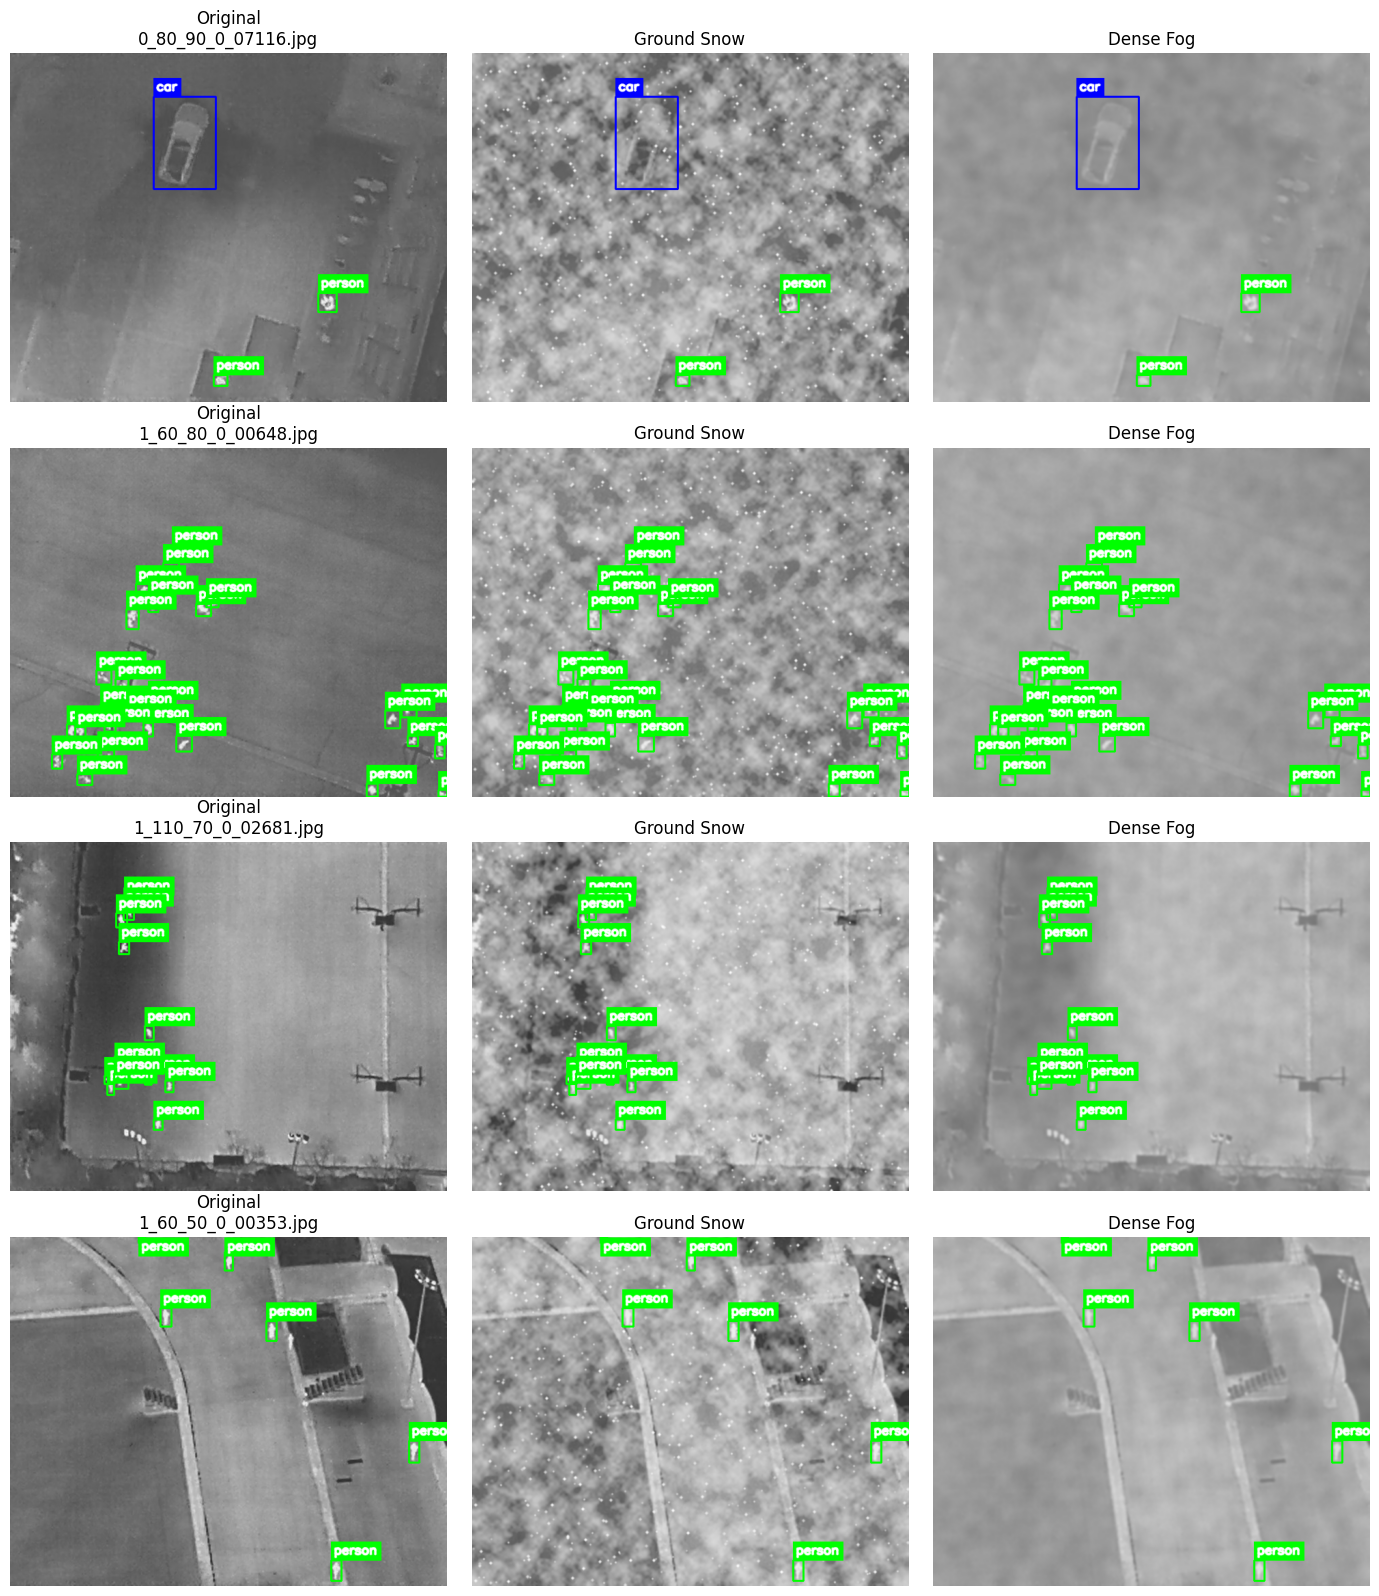


Augmentations saved to: /content/outputs/augmentations_with_labels.png

Testing random augmentations with rotations:


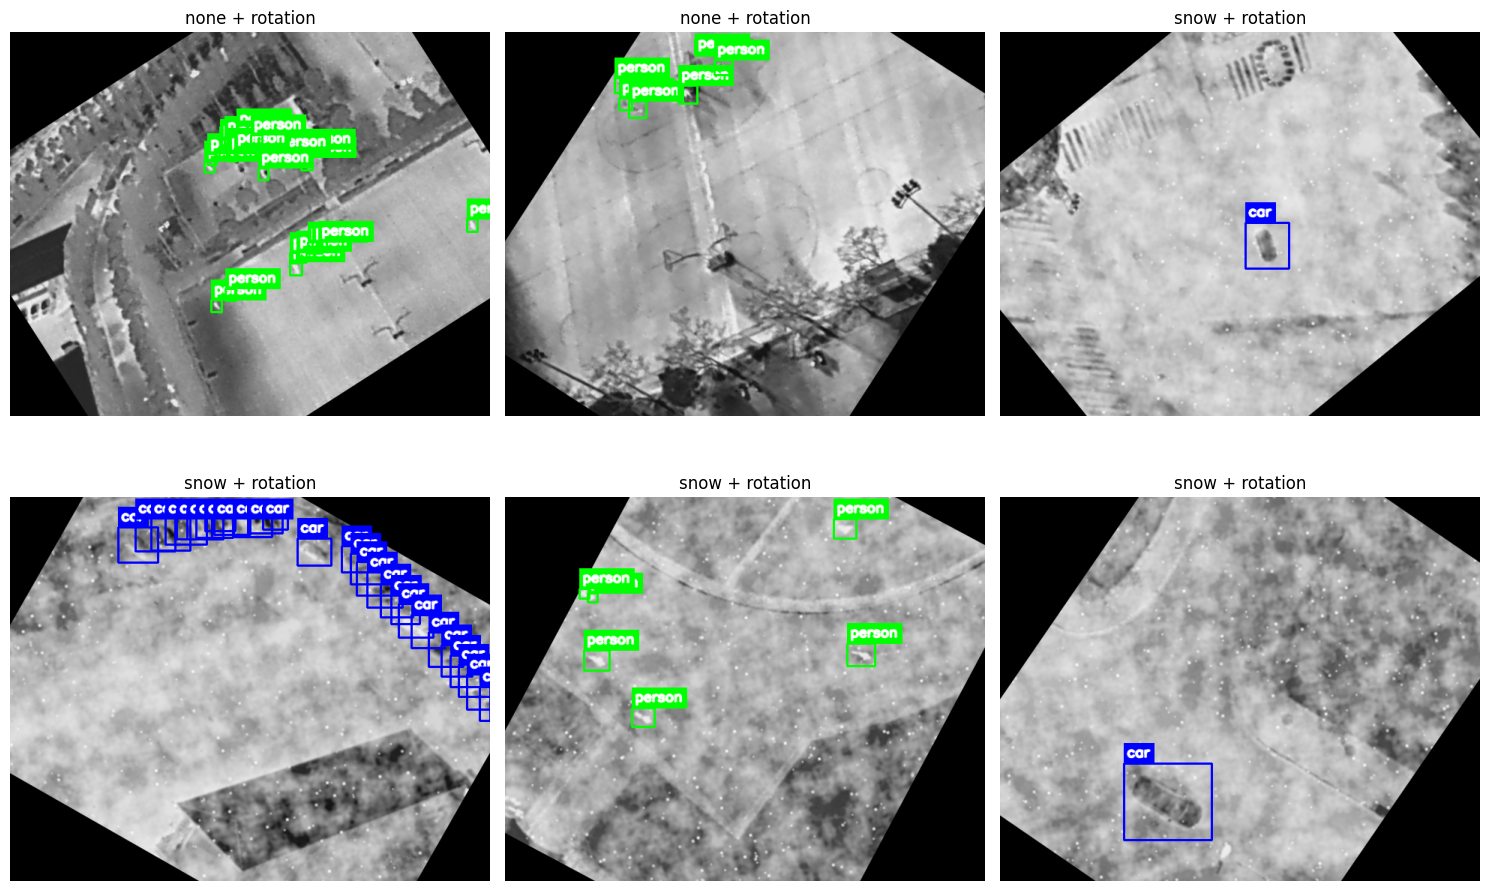

Random augmentations saved to: /content/outputs/augmentations_random_labeled.png

SAR augmentations ready!


In [ ]:
# =============================================================================
# CELL 5: SAR AUGMENTATIONS - SIMPLIFIED AND MORE VISIBLE
# =============================================================================

import albumentations as A
from albumentations.core.transforms_interface import ImageOnlyTransform
import numpy as np
import cv2

SAR_TARGET_CLASSES = {0, 1}  # person and car
SAR_CLASS_NAMES = {0: 'person', 1: 'car'}


class SnowEffect(ImageOnlyTransform):
    """Realistic snow effect - ground snow coverage with minimal falling snow."""
    def __init__(self, snow_coef=0.6, always_apply=False, p=0.5):
        super().__init__(always_apply, p)
        self.snow_coef = snow_coef

    def apply(self, img, **params):
        h, w = img.shape[:2]
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

        result = img.astype(np.float32)

        # Create snow ground texture using multi-scale noise
        snow_texture = np.zeros((h, w), dtype=np.float32)

        # Large patches (main snow coverage)
        large_noise = cv2.resize(np.random.randn(h//20, w//20), (w, h), interpolation=cv2.INTER_CUBIC)
        large_noise = cv2.GaussianBlur(large_noise, (21, 21), 0)

        # Medium details (snow drifts)
        medium_noise = cv2.resize(np.random.randn(h//8, w//8), (w, h), interpolation=cv2.INTER_CUBIC)
        medium_noise = cv2.GaussianBlur(medium_noise, (11, 11), 0)

        # Fine details (snow texture)
        fine_noise = cv2.resize(np.random.randn(h//4, w//4), (w, h), interpolation=cv2.INTER_CUBIC)
        fine_noise = cv2.GaussianBlur(fine_noise, (5, 5), 0)

        # Combine scales
        snow_texture = 0.5 * large_noise + 0.3 * medium_noise + 0.2 * fine_noise

        # Normalize to 0-1
        snow_texture = (snow_texture - snow_texture.min()) / (snow_texture.max() - snow_texture.min() + 1e-8)

        # Threshold to create snow patches (not uniform coverage)
        snow_mask = np.clip((snow_texture - 0.3) * 2, 0, 1)
        snow_mask = snow_mask ** 0.7  # Adjust distribution

        # Apply white snow to ground
        snow_color = 240  # Bright white-ish
        for c in range(3):
            snow_layer = result[:, :, c] * (1 - snow_mask * self.snow_coef) + snow_color * snow_mask * self.snow_coef
            result[:, :, c] = snow_layer

        # Add minimal falling snow (sparse)
        num_flakes = int(self.snow_coef * 800)  # Much fewer flakes
        for _ in range(num_flakes):
            x = np.random.randint(0, w)
            y = np.random.randint(0, h)
            radius = np.random.randint(1, 3)  # Smaller flakes
            brightness = np.random.randint(200, 255)
            cv2.circle(result, (x, y), radius, (brightness, brightness, brightness), -1)

        # Slight blur for atmospheric effect
        result = cv2.GaussianBlur(result.astype(np.uint8), (3, 3), 0)

        return result

    def get_transform_init_args_names(self):
        return ("snow_coef",)


class SmokeFireEffect(ImageOnlyTransform):
    """Dense white/gray smoke clouds - foggy appearance."""
    def __init__(self, smoke_intensity=0.7, always_apply=False, p=0.5):
        super().__init__(always_apply, p)
        self.smoke_intensity = smoke_intensity

    def apply(self, img, **params):
        h, w = img.shape[:2]
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

        result = img.astype(np.float32)

        # Create dense white-gray fog
        fog = np.ones((h, w, 3), dtype=np.float32) * 200  # Light gray base

        # Add variation with noise
        noise = np.random.randn(h, w).astype(np.float32)
        noise = cv2.GaussianBlur(noise, (51, 51), 0)
        noise = (noise - noise.min()) / (noise.max() - noise.min() + 1e-8)

        # Apply noise to create patchy fog
        for c in range(3):
            fog[:, :, c] = 180 + noise * 60  # White-gray variation

        # Heavy fog overlay
        alpha = self.smoke_intensity * 0.6
        result = cv2.addWeighted(result, 1 - alpha, fog, alpha, 0)

        # Additional blur for foggy look
        result = cv2.GaussianBlur(result.astype(np.uint8), (7, 7), 0)

        return result

    def get_transform_init_args_names(self):
        return ("smoke_intensity",)


def get_sar_augmentation_pipeline(p=0.5):
    """SAR augmentation pipeline."""
    return A.Compose([
        A.Rotate(limit=180, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.OneOf([
            SnowEffect(snow_coef=0.7, p=1.0),
            SmokeFireEffect(smoke_intensity=0.75, p=1.0),
        ], p=p),
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
            A.RandomGamma(gamma_limit=(80, 120), p=1.0),
        ], p=0.3),
        A.GaussNoise(var_limit=(10.0, 40.0), p=0.15),
    ], bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels'],
        min_visibility=0.3
    ))


def filter_sar_relevant_labels(label_path, target_classes=SAR_TARGET_CLASSES):
    """Filter labels to SAR-relevant classes."""
    filtered_labels = []
    if not label_path.exists():
        return filtered_labels

    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls_id = int(parts[0])
                if cls_id in target_classes:
                    cx, cy, bw, bh = map(float, parts[1:5])
                    filtered_labels.append((cls_id, cx, cy, bw, bh))

    return filtered_labels


def draw_labeled_boxes(img, boxes, labels, scores=None, class_names=SAR_CLASS_NAMES,
                       colors=None, thickness=2, font_scale=0.6):
    """
    Draw bounding boxes with class labels and confidence scores.

    Args:
        img: Image (BGR or RGB format)
        boxes: List of boxes in [x1, y1, x2, y2] pixel format
        labels: List of class IDs (0=person, 1=car)
        scores: List of confidence scores (0-1), optional
        class_names: Dict mapping class ID to name
        colors: Dict mapping class ID to BGR color
        thickness: Box line thickness
        font_scale: Label font scale
    """
    if colors is None:
        colors = {
            0: (0, 255, 0),    # Green for person
            1: (255, 0, 0),    # Blue for car
        }

    result = img.copy()

    for idx, (box, label) in enumerate(zip(boxes, labels)):
        x1, y1, x2, y2 = map(int, box)
        color = colors.get(label, (0, 255, 255))
        class_name = class_names.get(label, f'class_{label}')

        # Draw box
        cv2.rectangle(result, (x1, y1), (x2, y2), color, thickness)

        # Create label text with confidence if available
        if scores is not None and idx < len(scores):
            label_text = f'{class_name} {scores[idx]:.2f}'
        else:
            label_text = class_name

        # Calculate text size
        (text_w, text_h), baseline = cv2.getTextSize(
            label_text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness=2
        )

        # Draw background rectangle for text
        label_y = max(y1 - 5, text_h + 10)
        cv2.rectangle(result,
                     (x1, label_y - text_h - 8),
                     (x1 + text_w + 8, label_y + 5),
                     color, -1)

        # Draw text with white color for better readability
        cv2.putText(result, label_text,
                   (x1 + 4, label_y - 4),
                   cv2.FONT_HERSHEY_SIMPLEX,
                   font_scale,
                   (255, 255, 255),
                   thickness=2,
                   lineType=cv2.LINE_AA)

    return result


class SARaugmentations:
    """SAR augmentations wrapper."""
    _pipeline = None

    @classmethod
    def get_pipeline(cls):
        if cls._pipeline is None:
            cls._pipeline = get_sar_augmentation_pipeline(p=0.7)
        return cls._pipeline

    @staticmethod
    def apply_snow(img: np.ndarray, intensity: float = 0.7) -> np.ndarray:
        """Apply realistic ground snow effect."""
        transform = SnowEffect(snow_coef=intensity, always_apply=True)
        return transform(image=img)['image']

    @staticmethod
    def apply_smoke_fire(img: np.ndarray, smoke_intensity: float = 0.75) -> np.ndarray:
        """Apply dense fog/smoke effect."""
        transform = SmokeFireEffect(smoke_intensity=smoke_intensity, always_apply=True)
        return transform(image=img)['image']

    @staticmethod
    def apply_with_bboxes(img: np.ndarray, bboxes: list, class_labels: list):
        """Apply augmentations with bounding box support."""
        filtered_bboxes = []
        filtered_labels = []
        for bbox, label in zip(bboxes, class_labels):
            if label in SAR_TARGET_CLASSES:
                filtered_bboxes.append(bbox)
                filtered_labels.append(label)

        if len(filtered_bboxes) == 0:
            return img, [], []

        pipeline = SARaugmentations.get_pipeline()
        transformed = pipeline(
            image=img,
            bboxes=filtered_bboxes,
            class_labels=filtered_labels
        )

        return transformed['image'], transformed['bboxes'], transformed['class_labels']

    @staticmethod
    def apply_random(img: np.ndarray) -> tuple:
        """Apply random augmentation."""
        aug_type = np.random.choice(['snow', 'smoke', 'none'])

        if aug_type == 'snow':
            return SARaugmentations.apply_snow(img, 0.7), 'snow'
        elif aug_type == 'smoke':
            return SARaugmentations.apply_smoke_fire(img, 0.75), 'fog/smoke'

        return img, 'none'


# =============================================================================
# VISUALIZATION
# =============================================================================

print(f"{'='*70}")
print("SAR Augmentations - Enhanced Visibility")
print(f"{'='*70}")
print(f"Target classes: Person (0), Car (1)")
print(f"Augmentations: Realistic Ground Snow, Dense Fog/Smoke")

sample_imgs = list(IMAGES_DIR.glob("*.jpg"))

if len(sample_imgs) > 0:
    samples_with_sar_labels = []
    for img_path in sample_imgs:
        label_path = LABELS_DIR / f"{img_path.stem}.txt"
        labels = filter_sar_relevant_labels(label_path)
        if len(labels) > 0:
            samples_with_sar_labels.append((img_path, labels))

    samples_to_show = random.sample(samples_with_sar_labels, min(4, len(samples_with_sar_labels)))

    print(f"\nShowing {len(samples_to_show)} images with Person/Car labels:")
    for img_path, labels in samples_to_show:
        label_counts = {}
        for lbl in labels:
            name = SAR_CLASS_NAMES.get(lbl[0], 'unknown')
            label_counts[name] = label_counts.get(name, 0) + 1
        print(f"  - {img_path.name}: {label_counts}")

    # Visualization: Original, Snow, Fog
    fig, axes = plt.subplots(len(samples_to_show), 3, figsize=(14, 4 * len(samples_to_show)))
    if len(samples_to_show) == 1:
        axes = axes.reshape(1, -1)

    for row_idx, (img_path, yolo_labels) in enumerate(samples_to_show):
        sample = cv2.imread(str(img_path))
        if sample is None:
            continue

        h, w = sample.shape[:2]

        # Convert YOLO to pixel coordinates
        boxes_pixel = []
        class_ids = []
        for lbl in yolo_labels:
            cls_id, cx, cy, bw, bh = lbl
            x1 = int((cx - bw / 2) * w)
            y1 = int((cy - bh / 2) * h)
            x2 = int((cx + bw / 2) * w)
            y2 = int((cy + bh / 2) * h)
            boxes_pixel.append([x1, y1, x2, y2])
            class_ids.append(cls_id)

        # Original
        original_labeled = draw_labeled_boxes(sample, boxes_pixel, class_ids)
        axes[row_idx, 0].imshow(cv2.cvtColor(original_labeled, cv2.COLOR_BGR2RGB))
        axes[row_idx, 0].set_title(f'Original\n{img_path.name}')
        axes[row_idx, 0].axis('off')

        # Snow
        snow_aug = SARaugmentations.apply_snow(sample, 0.7)
        snow_labeled = draw_labeled_boxes(snow_aug, boxes_pixel, class_ids)
        axes[row_idx, 1].imshow(cv2.cvtColor(snow_labeled, cv2.COLOR_BGR2RGB))
        axes[row_idx, 1].set_title('Ground Snow')
        axes[row_idx, 1].axis('off')

        # Fog/Smoke
        smoke_aug = SARaugmentations.apply_smoke_fire(sample, 0.75)
        smoke_labeled = draw_labeled_boxes(smoke_aug, boxes_pixel, class_ids)
        axes[row_idx, 2].imshow(cv2.cvtColor(smoke_labeled, cv2.COLOR_BGR2RGB))
        axes[row_idx, 2].set_title('Dense Fog')
        axes[row_idx, 2].axis('off')

    plt.tight_layout()
    plt.savefig(f"{Config.OUTPUT_DIR}/augmentations_with_labels.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nAugmentations saved to: {Config.OUTPUT_DIR}/augmentations_with_labels.png")

    # Test random augmentation
    print(f"\n{'='*70}")
    print("Testing random augmentations with rotations:")
    print(f"{'='*70}")

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx in range(6):
        img_path, yolo_labels = random.choice(samples_with_sar_labels)
        sample_img = cv2.imread(str(img_path))
        if sample_img is not None:
            h, w = sample_img.shape[:2]

            # Keep boxes in YOLO format (normalized) for Albumentations
            yolo_boxes = []
            class_ids = []
            for lbl in yolo_labels:
                cls_id, cx, cy, bw, bh = lbl
                yolo_boxes.append([cx, cy, bw, bh])
                class_ids.append(cls_id)

            # Apply perturbation first (image-only)
            aug_img, aug_type = SARaugmentations.apply_random(sample_img)

            # Apply rotation WITH bbox transformation using proper pipeline
            rotation_pipeline = A.Compose([
                A.Rotate(limit=180, border_mode=cv2.BORDER_CONSTANT, value=0, p=1.0)
            ], bbox_params=A.BboxParams(
                format='yolo',
                label_fields=['class_labels'],
                min_visibility=0.3
            ))

            transformed = rotation_pipeline(
                image=aug_img,
                bboxes=yolo_boxes,
                class_labels=class_ids
            )
            aug_img = transformed['image']
            transformed_boxes = transformed['bboxes']
            transformed_labels = transformed['class_labels']

            # Convert transformed YOLO boxes back to pixel coordinates for drawing
            h_new, w_new = aug_img.shape[:2]
            boxes_pixel = []
            for box in transformed_boxes:
                cx, cy, bw, bh = box
                x1 = int((cx - bw / 2) * w_new)
                y1 = int((cy - bh / 2) * h_new)
                x2 = int((cx + bw / 2) * w_new)
                y2 = int((cy + bh / 2) * h_new)
                boxes_pixel.append([x1, y1, x2, y2])

            aug_labeled = draw_labeled_boxes(aug_img, boxes_pixel, transformed_labels)

            axes[idx].imshow(cv2.cvtColor(aug_labeled, cv2.COLOR_BGR2RGB))
            axes[idx].set_title(f'{aug_type} + rotation')
            axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(f"{Config.OUTPUT_DIR}/augmentations_random_labeled.png", dpi=150)
    plt.show()
    print(f"Random augmentations saved to: {Config.OUTPUT_DIR}/augmentations_random_labeled.png")

else:
    print("WARNING: No images found.")

print(f"\n{'='*70}")
print("SAR augmentations ready!")
print(f"{'='*70}")

## Cell 6: UAV Detection Dataset Class

Custom PyTorch Dataset for loading HIT-UAV thermal images with YOLO-format labels.

### Key Features
- **Automatic label parsing**: Converts YOLO format (class, x_center, y_center, w, h) to absolute coordinates
- **Augmentation integration**: Optional SAR augmentation with configurable probability
- **Robust box handling**: Filters invalid boxes (zero area, out of bounds)

### Parameters
| Parameter | Description |
|-----------|-------------|
| `apply_sar_aug` | Enable/disable SAR augmentations |
| `sar_aug_prob` | Probability of applying augmentation (0.0-1.0) |
| `selected_files` | Subset of files for train/val/test split |

### Output Format
Returns `(image_tensor, target_dict)` where target_dict contains:
- `boxes`: [N, 4] tensor of bounding boxes (x1, y1, x2, y2)
- `labels`: [N] tensor of class IDs
- `area`: [N] tensor of box areas
- `iscrowd`: [N] tensor (always 0 for this dataset)


Creating train/val/test splits
No predefined splits found; creating random 70/15/15 split from images/labels.
train: 2006 images
val:   430 images
test:  430 images
Dataset initialized (YOLO): 2006 images with labels
  - Images dir: /content/hit-uav/images
  - Labels dir:  /content/hit-uav/labels
  - SAR augmentation: Disabled (p=1.0)
Dataset initialized (YOLO): 2006 images with labels
  - Images dir: /content/hit-uav/images
  - Labels dir:  /content/hit-uav/labels
  - SAR augmentation: Enabled (p=1.0)

Loading and visualizing samples...


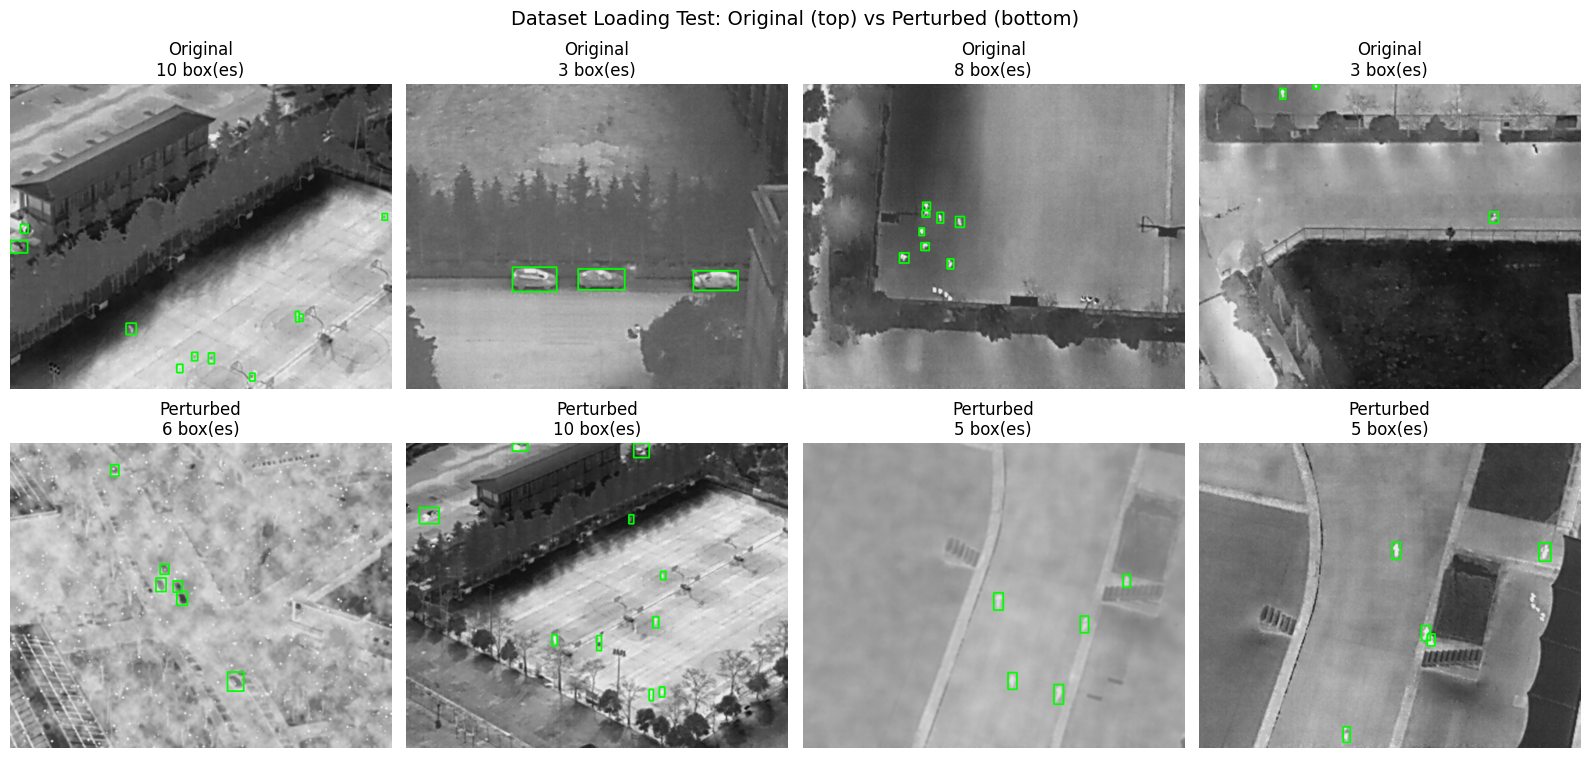


Dataset loading test saved to: /content/outputs/dataset_loading_test.png
Dataset class and splits created successfully!


In [ ]:

# =============================================================================
# CELL 6: DATASET CLASS
# Proper handling of box formats; uses native YOLO labels directly (no COCO conversion)
# =============================================================================

CLASS_NAMES = ['person', 'car', 'bicycle', 'othervehicle', 'dontcare']

class UAVDetectionDataset(Dataset):
    """
    Dataset for UAV detection using YOLO .txt labels directly.
    All classes are retained; labels are shifted by +1 to reserve 0 for background.
    """
    def __init__(self, images_dir, labels_dir, transforms=None,
                 apply_sar_aug=False, sar_aug_prob=1.0, selected_files=None):
        self.images_dir = Path(images_dir)
        self.labels_dir = Path(labels_dir)
        self.transforms = transforms
        self.apply_sar_aug = apply_sar_aug
        self.sar_aug_prob = sar_aug_prob
        candidate_files = selected_files if selected_files is not None else (
            list(self.images_dir.glob('*.jpg')) + list(self.images_dir.glob('*.png'))
        )
        self.image_files = [Path(p) for p in candidate_files
                            if (self.labels_dir / f"{Path(p).stem}.txt").exists()]
        self.img_ids = list(range(len(self.image_files)))
        print(f"Dataset initialized (YOLO): {len(self.img_ids)} images with labels")
        print(f"  - Images dir: {self.images_dir}")
        print(f"  - Labels dir:  {self.labels_dir}")
        print(f"  - SAR augmentation: {'Enabled' if self.apply_sar_aug else 'Disabled'} (p={self.sar_aug_prob})")

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # Read YOLO labels
        label_path = self.labels_dir / f"{img_path.stem}.txt"
        boxes = []
        labels = []
        areas = []
        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls_id = int(parts[0])
                        cx, cy, bw, bh = map(float, parts[1:5])
                        x = (cx - bw / 2) * w
                        y = (cy - bh / 2) * h
                        bw_pix = bw * w
                        bh_pix = bh * h
                        x1, y1, x2, y2 = x, y, x + bw_pix, y + bh_pix
                        if x2 > x1 and y2 > y1:
                            boxes.append([x1, y1, x2, y2])
                            labels.append(cls_id + 1)  # shift for background index 0
                            areas.append(bw_pix * bh_pix)

        # Apply perturbations to every image if enabled
        if self.apply_sar_aug and random.random() < self.sar_aug_prob:
            img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            img_aug, _ = SARaugmentations.apply_random(img_bgr)
            img = cv2.cvtColor(img_aug, cv2.COLOR_BGR2RGB)

        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        if self.transforms:
            img_tensor = self.transforms(img_tensor)

        if len(boxes) > 0:
            boxes_tensor = torch.as_tensor(boxes, dtype=torch.float32)
            labels_tensor = torch.as_tensor(labels, dtype=torch.int64)
            areas_tensor = torch.as_tensor(areas, dtype=torch.float32)
        else:
            boxes_tensor = torch.zeros((0, 4), dtype=torch.float32)
            labels_tensor = torch.zeros((0,), dtype=torch.int64)
            areas_tensor = torch.zeros((0,), dtype=torch.float32)

        target = {
            'boxes': boxes_tensor,
            'labels': labels_tensor,
            'image_id': torch.tensor([idx]),
            'area': areas_tensor,
            'iscrowd': torch.zeros(len(boxes), dtype=torch.int64)
        }

        return img_tensor, target


def collate_fn(batch):
    """Custom collate for detection."""
    return tuple(zip(*batch))

# Create train/val/test split (70/15/15)

# Create train/val/test split (70/15/15)
print(f"\n{'='*70}")
print("Creating train/val/test splits")
print(f"{'='*70}")

split_roots = {name: Config.DATA_ROOT / name for name in ['train','val','test']}
predefined = all((split_roots[name] / 'images').exists() and (split_roots[name] / 'labels').exists() for name in split_roots)

if predefined:
    print("Found predefined splits on disk; using them without reshuffling.")
    TRAIN_FILES = sorted(list((split_roots['train']/ 'images').glob('*.jpg')) + list((split_roots['train']/ 'images').glob('*.png')))
    VAL_FILES   = sorted(list((split_roots['val']  / 'images').glob('*.jpg')) + list((split_roots['val']  / 'images').glob('*.png')))
    TEST_FILES  = sorted(list((split_roots['test'] / 'images').glob('*.jpg')) + list((split_roots['test'] / 'images').glob('*.png')))
else:
    print("No predefined splits found; creating random 70/15/15 split from images/labels.")
    all_images = sorted(list((Config.DATA_ROOT / 'images').glob('*.jpg')) + list((Config.DATA_ROOT / 'images').glob('*.png')))
    all_images = [p for p in all_images if (Config.DATA_ROOT / 'labels' / f"{p.stem}.txt").exists()]
    random.shuffle(all_images)
    n = len(all_images)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)
    TRAIN_FILES = all_images[:train_end]
    VAL_FILES = all_images[train_end:val_end]
    TEST_FILES = all_images[val_end:]

print(f"train: {len(TRAIN_FILES)} images")
print(f"val:   {len(VAL_FILES)} images")
print(f"test:  {len(TEST_FILES)} images")

test_dataset_no_aug = UAVDetectionDataset(Config.DATA_ROOT / 'images', Config.DATA_ROOT / 'labels',
    apply_sar_aug=False, selected_files=TRAIN_FILES)
test_dataset_with_aug = UAVDetectionDataset(Config.DATA_ROOT / 'images', Config.DATA_ROOT / 'labels',
    apply_sar_aug=True, sar_aug_prob=1.0, selected_files=TRAIN_FILES)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
print("\nLoading and visualizing samples...")

for col in range(4):
    idx = random.randint(0, len(test_dataset_no_aug) - 1)
    img_tensor, target = test_dataset_no_aug[idx]
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = (img_np * 255).astype(np.uint8)
    boxes = target['boxes'].numpy()
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img_np, (x1, y1), (x2, y2), (0, 255, 0), 2)
    axes[0, col].imshow(img_np)
    axes[0, col].set_title(f'Original\n{len(boxes)} box(es)')
    axes[0, col].axis('off')

for col in range(4):
    idx = random.randint(0, len(test_dataset_with_aug) - 1)
    img_tensor, target = test_dataset_with_aug[idx]
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = (img_np * 255).astype(np.uint8)
    boxes = target['boxes'].numpy()
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img_np, (x1, y1), (x2, y2), (0, 255, 0), 2)
    axes[1, col].imshow(img_np)
    axes[1, col].set_title(f'Perturbed\n{len(boxes)} box(es)')
    axes[1, col].axis('off')

plt.suptitle('Dataset Loading Test: Original (top) vs Perturbed (bottom)', fontsize=14)
plt.tight_layout()
plt.savefig(f"{Config.OUTPUT_DIR}/dataset_loading_test.png", dpi=150)
plt.show()

print(f"\nDataset loading test saved to: {Config.OUTPUT_DIR}/dataset_loading_test.png")
print(f"{'='*70}")
print("Dataset class and splits created successfully!")
print(f"{'='*70}")


## Cell 7: Enhanced Evaluation Function

Implements comprehensive object detection evaluation with IoU-based metrics.

### Metrics Computed

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Precision** | TP / (TP + FP) | How many predictions are correct? |
| **Recall** | TP / (TP + FN) | How many ground truth objects are found? |
| **F1 Score** | 2×P×R / (P+R) | Balanced metric (harmonic mean) |
| **Mean IoU** | Avg IoU of matched detections | Localization quality |

### AP@IoU Metrics (COCO-style)

| Metric | Description |
|--------|-------------|
| **AP@0.50** | Average Precision at IoU=0.50 (PASCAL VOC metric) |
| **AP@0.75** | Average Precision at IoU=0.75 (stricter localization) |
| **AP@0.50:0.95** | Mean AP across IoU thresholds 0.50 to 0.95 (COCO primary metric) |

### Visualization Functions
- `plot_ap_iou_curve()`: Compare AP across IoU thresholds for multiple models
- `plot_iou_distribution()`: Histogram of IoU values for matched detections

### Thresholds
- `iou_thresh=0.5`: Standard threshold for correct detection
- `conf_thresh=0.5`: Minimum confidence to count as detection

In [ ]:
# =============================================================================
# CELL 7: ENHANCED EVALUATION FUNCTION
# Computes precision, recall, F1, mean IoU, and AP@multiple IoU thresholds
# =============================================================================

def compute_iou(box1, box2):
    """
    Compute IoU between two boxes in [x1, y1, x2, y2] format.
    """
    # Intersection
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter_area = inter_w * inter_h

    # Union
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = area1 + area2 - inter_area

    if union_area <= 0:
        return 0.0

    return inter_area / union_area


@torch.no_grad()
def evaluate_model(model, data_loader, device, iou_thresh=0.5, conf_thresh=0.5, verbose=False):
    """
    Evaluate detection model with comprehensive metrics.

    Returns:
        dict with precision, recall, F1, mean_iou, and counts at given IoU threshold.
    """
    model.eval()

    total_tp = 0
    total_fp = 0
    total_fn = 0
    total_gt = 0
    total_pred = 0
    matched_ious = []  # Store IoU values of matched predictions

    for batch_idx, (images, targets) in enumerate(tqdm(data_loader, desc="Evaluating", disable=not verbose)):
        images = [img.to(device) for img in images]

        # Get predictions
        outputs = model(images)

        for output, target in zip(outputs, targets):
            # Get ground truth boxes (already in [x1, y1, x2, y2] format from dataset)
            gt_boxes = target['boxes'].cpu().numpy()
            total_gt += len(gt_boxes)

            # Filter predictions by confidence
            scores = output['scores'].cpu().numpy()
            pred_boxes = output['boxes'].cpu().numpy()

            mask = (scores >= conf_thresh)
            pred_boxes = pred_boxes[mask]
            pred_scores = scores[mask]
            total_pred += len(pred_boxes)

            if len(gt_boxes) == 0:
                total_fp += len(pred_boxes)
                continue

            if len(pred_boxes) == 0:
                total_fn += len(gt_boxes)
                continue

            # Match predictions to ground truth (greedy matching by score)
            sorted_indices = np.argsort(-pred_scores)
            matched_gt = set()

            for pred_idx in sorted_indices:
                pred_box = pred_boxes[pred_idx]

                best_iou = 0
                best_gt_idx = -1

                for gt_idx, gt_box in enumerate(gt_boxes):
                    if gt_idx in matched_gt:
                        continue

                    iou = compute_iou(pred_box, gt_box)
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = gt_idx

                if best_iou >= iou_thresh and best_gt_idx >= 0:
                    total_tp += 1
                    matched_gt.add(best_gt_idx)
                    matched_ious.append(best_iou)  # Track IoU of matched predictions
                else:
                    total_fp += 1

            # Unmatched ground truths are false negatives
            total_fn += len(gt_boxes) - len(matched_gt)

    # Compute metrics
    precision = total_tp / max(total_tp + total_fp, 1)
    recall = total_tp / max(total_tp + total_fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)
    mean_iou = np.mean(matched_ious) if matched_ious else 0.0

    metrics = {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'mean_iou': mean_iou,
        'tp': total_tp,
        'fp': total_fp,
        'fn': total_fn,
        'total_gt': total_gt,
        'total_pred': total_pred,
        'matched_ious': matched_ious  # For distribution analysis
    }

    if verbose:
        print(f"\nEvaluation Results (IoU>={iou_thresh}, Conf>={conf_thresh}):")
        print(f"  GT boxes: {total_gt}, Predictions: {total_pred}")
        print(f"  TP: {total_tp}, FP: {total_fp}, FN: {total_fn}")
        print(f"  Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
        print(f"  Mean IoU (matched): {mean_iou:.4f}")

    return metrics


@torch.no_grad()
def compute_ap_at_iou_thresholds(model, data_loader, device, conf_thresh=0.5,
                                   iou_thresholds=[0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]):
    """
    Compute Average Precision at multiple IoU thresholds (COCO-style evaluation).

    Returns:
        dict with AP@0.5, AP@0.75, AP@0.5:0.95, and per-threshold results
    """
    model.eval()

    # Collect all predictions and ground truths
    all_predictions = []  # List of (score, pred_box, gt_boxes_for_image)
    all_gt_counts = 0

    for images, targets in tqdm(data_loader, desc="Collecting predictions"):
        images = [img.to(device) for img in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):
            gt_boxes = target['boxes'].cpu().numpy()
            all_gt_counts += len(gt_boxes)

            scores = output['scores'].cpu().numpy()
            pred_boxes = output['boxes'].cpu().numpy()

            mask = scores >= conf_thresh
            for score, pred_box in zip(scores[mask], pred_boxes[mask]):
                all_predictions.append((score, pred_box, gt_boxes.copy()))

    # Sort all predictions by score (descending)
    all_predictions.sort(key=lambda x: -x[0])

    # Compute AP at each IoU threshold
    ap_results = {}

    for iou_thresh in iou_thresholds:
        tp_list = []
        fp_list = []

        # Track which GT boxes have been matched (per image - simplified approach)
        gt_matched = {}  # Maps gt_box tuple to matched status

        for score, pred_box, gt_boxes in all_predictions:
            best_iou = 0
            best_gt = None

            for gt_box in gt_boxes:
                gt_key = tuple(gt_box)
                if gt_key in gt_matched:
                    continue

                iou = compute_iou(pred_box, gt_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt = gt_key

            if best_iou >= iou_thresh and best_gt is not None:
                tp_list.append(1)
                fp_list.append(0)
                gt_matched[best_gt] = True
            else:
                tp_list.append(0)
                fp_list.append(1)

        # Compute precision-recall curve
        tp_cumsum = np.cumsum(tp_list)
        fp_cumsum = np.cumsum(fp_list)

        precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-8)
        recalls = tp_cumsum / (all_gt_counts + 1e-8)

        # Compute AP using 11-point interpolation (PASCAL VOC style)
        ap = 0
        for t in np.linspace(0, 1, 11):
            prec_at_recall = precisions[recalls >= t]
            if len(prec_at_recall) > 0:
                ap += np.max(prec_at_recall)
        ap /= 11

        ap_results[f'AP@{iou_thresh:.2f}'] = ap

    # Compute summary metrics
    ap_results['AP@0.50'] = ap_results.get('AP@0.50', 0)
    ap_results['AP@0.75'] = ap_results.get('AP@0.75', 0)
    ap_results['AP@0.50:0.95'] = np.mean([ap_results[f'AP@{t:.2f}'] for t in iou_thresholds])
    ap_results['iou_thresholds'] = iou_thresholds
    ap_results['ap_values'] = [ap_results[f'AP@{t:.2f}'] for t in iou_thresholds]

    return ap_results


def plot_ap_iou_curve(ap_results_dict, title="AP vs IoU Threshold", save_path=None):
    """
    Plot AP@IoU curves for multiple models.

    Args:
        ap_results_dict: Dict mapping model names to their ap_results
        title: Plot title
        save_path: Optional path to save the figure
    """
    plt.figure(figsize=(10, 6))

    colors = ['blue', 'red', 'green', 'orange']
    markers = ['o', 's', '^', 'd']

    for idx, (name, results) in enumerate(ap_results_dict.items()):
        iou_thresholds = results['iou_thresholds']
        ap_values = results['ap_values']

        plt.plot(iou_thresholds, ap_values,
                 color=colors[idx % len(colors)],
                 marker=markers[idx % len(markers)],
                 linewidth=2, markersize=8,
                 label=f"{name} (mAP={results['AP@0.50:0.95']:.3f})")

    plt.xlabel('IoU Threshold', fontsize=12)
    plt.ylabel('Average Precision (AP)', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xlim(0.45, 1.0)
    plt.ylim(0, 1.0)

    # Add vertical lines at key thresholds
    plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='IoU=0.5')
    plt.axvline(x=0.75, color='gray', linestyle='--', alpha=0.5, label='IoU=0.75')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved AP-IoU curve to {save_path}")

    plt.show()


def plot_iou_distribution(matched_ious_dict, title="IoU Distribution of Matched Detections", save_path=None):
    """
    Plot histogram of IoU values for matched detections.

    Args:
        matched_ious_dict: Dict mapping model names to their matched_ious lists
    """
    fig, axes = plt.subplots(1, len(matched_ious_dict), figsize=(6*len(matched_ious_dict), 5))
    if len(matched_ious_dict) == 1:
        axes = [axes]

    colors = ['blue', 'red', 'green', 'orange']

    for idx, (name, ious) in enumerate(matched_ious_dict.items()):
        ax = axes[idx]
        if len(ious) > 0:
            ax.hist(ious, bins=20, range=(0.5, 1.0),
                    color=colors[idx % len(colors)], alpha=0.7, edgecolor='black')
            ax.axvline(np.mean(ious), color='red', linestyle='--',
                       linewidth=2, label=f'Mean: {np.mean(ious):.3f}')
            ax.axvline(np.median(ious), color='green', linestyle='--',
                       linewidth=2, label=f'Median: {np.median(ious):.3f}')

        ax.set_xlabel('IoU', fontsize=11)
        ax.set_ylabel('Count', fontsize=11)
        ax.set_title(f'{name}\n(n={len(ious)} matches)', fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved IoU distribution to {save_path}")

    plt.show()


print("Enhanced evaluation functions defined (with mIoU and AP@IoU support)")

Enhanced evaluation functions defined (with mIoU and AP@IoU support)


In [ ]:
# =============================================================================
# CELL 7.1: NAIVE BASELINE - RANDOM DETECTOR
# =============================================================================
# This model serves as a lower bound for comparison.
# It generates random bounding box predictions based on training set statistics.

import pickle

class NaiveRandomDetector:
    """
    Naive baseline detector that generates random predictions.

    Strategy: Learn average number of objects and typical box sizes from training data,
    then generate random predictions based on these statistics.
    """

    def __init__(self):
        self.avg_num_objects = 5
        self.avg_box_width = 0.05  # Normalized
        self.avg_box_height = 0.06  # Normalized
        self.std_box_width = 0.02
        self.std_box_height = 0.02
        self.class_distribution = {1: 0.6, 2: 0.4}  # person vs car

    def fit(self, images_dir, labels_dir, image_files):
        """Learn statistics from training data."""
        print("Naive Baseline: Learning statistics from training data...")

        all_num_objects = []
        all_widths = []
        all_heights = []
        class_counts = defaultdict(int)

        for img_path in tqdm(image_files, desc="Analyzing training labels"):
            label_path = labels_dir / f"{img_path.stem}.txt"
            if not label_path.exists():
                continue

            with open(label_path, 'r') as f:
                lines = f.readlines()
                num_objects = len(lines)
                all_num_objects.append(num_objects)

                for line in lines:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls_id = int(parts[0]) + 1  # Shift for background
                        bw, bh = float(parts[3]), float(parts[4])
                        all_widths.append(bw)
                        all_heights.append(bh)
                        class_counts[cls_id] += 1

        if len(all_num_objects) > 0:
            self.avg_num_objects = np.mean(all_num_objects)
            self.std_num_objects = np.std(all_num_objects)
        if len(all_widths) > 0:
            self.avg_box_width = np.mean(all_widths)
            self.std_box_width = np.std(all_widths)
        if len(all_heights) > 0:
            self.avg_box_height = np.mean(all_heights)
            self.std_box_height = np.std(all_heights)

        total_objects = sum(class_counts.values())
        if total_objects > 0:
            self.class_distribution = {k: v/total_objects for k, v in class_counts.items()}

        print(f"  Avg objects per image: {self.avg_num_objects:.1f}")
        print(f"  Avg box size: {self.avg_box_width:.3f} x {self.avg_box_height:.3f}")
        print(f"  Class distribution: {self.class_distribution}")

    def predict(self, img_tensor):
        """Generate random predictions for an image."""
        _, h, w = img_tensor.shape

        # Random number of predictions (Poisson-like)
        num_preds = max(0, int(np.random.normal(self.avg_num_objects, self.std_num_objects)))
        num_preds = min(num_preds, 20)  # Cap at 20

        boxes = []
        labels = []
        scores = []

        for _ in range(num_preds):
            # Random box size
            bw = max(0.02, np.random.normal(self.avg_box_width, self.std_box_width))
            bh = max(0.02, np.random.normal(self.avg_box_height, self.std_box_height))

            # Random center position
            cx = np.random.uniform(bw/2, 1 - bw/2)
            cy = np.random.uniform(bh/2, 1 - bh/2)

            # Convert to pixel coordinates
            x1 = int((cx - bw/2) * w)
            y1 = int((cy - bh/2) * h)
            x2 = int((cx + bw/2) * w)
            y2 = int((cy + bh/2) * h)

            # Ensure valid box
            x1, x2 = max(0, x1), min(w, x2)
            y1, y2 = max(0, y1), min(h, y2)

            if x2 > x1 and y2 > y1:
                boxes.append([x1, y1, x2, y2])

                # Random class based on distribution
                cls = np.random.choice(
                    list(self.class_distribution.keys()),
                    p=list(self.class_distribution.values())
                )
                labels.append(cls)

                # Random confidence score
                scores.append(np.random.uniform(0.3, 0.9))

        return {
            'boxes': torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4)),
            'labels': torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64),
            'scores': torch.tensor(scores, dtype=torch.float32) if scores else torch.zeros((0,))
        }

    def __call__(self, images):
        """Batch prediction interface (mimics PyTorch model)."""
        return [self.predict(img) for img in images]

    def eval(self):
        """Compatibility with PyTorch model interface."""
        pass

    def to(self, device):
        """Compatibility with PyTorch model interface."""
        return self


class AlwaysNegativeDetector:
    """
    Even simpler baseline: always predicts no objects.
    Useful for understanding the class imbalance.
    """

    def predict(self, img_tensor):
        return {
            'boxes': torch.zeros((0, 4), dtype=torch.float32),
            'labels': torch.zeros((0,), dtype=torch.int64),
            'scores': torch.zeros((0,), dtype=torch.float32)
        }

    def __call__(self, images):
        return [self.predict(img) for img in images]

    def eval(self):
        pass

    def to(self, device):
        return self


# Train and evaluate naive baseline
print("="*70)
print("NAIVE BASELINE MODEL")
print("="*70)

naive_detector = NaiveRandomDetector()
naive_detector.fit(IMAGES_DIR, LABELS_DIR, TRAIN_FILES)

# Evaluate on validation set (reuse val_dataset from earlier or create new one)
val_dataset_for_baseline = UAVDetectionDataset(
    IMAGES_DIR, LABELS_DIR,
    selected_files=VAL_FILES,
    apply_sar_aug=False
)

val_loader_baseline = DataLoader(
    val_dataset_for_baseline,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

print("\nEvaluating Random Detector on validation set...")
metrics_naive_random = evaluate_model(
    naive_detector, val_loader_baseline, Config.DEVICE,
    iou_thresh=Config.IOU_THRESHOLD,
    conf_thresh=0.3,  # Lower threshold since random scores
    verbose=True
)

print("\nEvaluating Always-Negative Detector on validation set...")
always_negative = AlwaysNegativeDetector()
metrics_naive_negative = evaluate_model(
    always_negative, val_loader_baseline, Config.DEVICE,
    iou_thresh=Config.IOU_THRESHOLD,
    conf_thresh=0.0,
    verbose=True
)

print("\n" + "="*70)
print("NAIVE BASELINE RESULTS")
print("="*70)
print(f"{'Model':<25} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-"*70)
print(f"{'Random Detector':<25} {metrics_naive_random['precision']:.4f}       {metrics_naive_random['recall']:.4f}       {metrics_naive_random['f1']:.4f}")
print(f"{'Always-Negative':<25} {metrics_naive_negative['precision']:.4f}       {metrics_naive_negative['recall']:.4f}       {metrics_naive_negative['f1']:.4f}")
print("="*70)
print("\nNaive baselines establish the lower bound for model performance.")
print("Any useful model should significantly outperform these baselines.")

NAIVE BASELINE MODEL
Naive Baseline: Learning statistics from training data...


Analyzing training labels:   0%|          | 0/2006 [00:00<?, ?it/s]

  Avg objects per image: 8.6
  Avg box size: 0.045 x 0.062
  Class distribution: {1: 0.4995965417867435, 2: 0.29510086455331414, 3: 0.19394812680115273, 4: 0.005648414985590778, 5: 0.005706051873198848}
Dataset initialized (YOLO): 430 images with labels
  - Images dir: /content/hit-uav/images
  - Labels dir:  /content/hit-uav/labels
  - SAR augmentation: Disabled (p=1.0)

Evaluating Random Detector on validation set...


Evaluating:   0%|          | 0/108 [00:00<?, ?it/s]


Evaluation Results (IoU>=0.5, Conf>=0.3):
  GT boxes: 3870, Predictions: 3541
  TP: 1, FP: 3540, FN: 3869
  Precision: 0.0003, Recall: 0.0003, F1: 0.0003
  Mean IoU (matched): 0.5180

Evaluating Always-Negative Detector on validation set...


Evaluating:   0%|          | 0/108 [00:00<?, ?it/s]


Evaluation Results (IoU>=0.5, Conf>=0.0):
  GT boxes: 3870, Predictions: 0
  TP: 0, FP: 0, FN: 3870
  Precision: 0.0000, Recall: 0.0000, F1: 0.0000
  Mean IoU (matched): 0.0000

NAIVE BASELINE RESULTS
Model                     Precision    Recall       F1          
----------------------------------------------------------------------
Random Detector           0.0003       0.0003       0.0003
Always-Negative           0.0000       0.0000       0.0000

Naive baselines establish the lower bound for model performance.
Any useful model should significantly outperform these baselines.


In [ ]:
# =============================================================================
# CELL 7.2: CLASSICAL ML MODEL - HOG + SVM DETECTOR
# =============================================================================
# Traditional computer vision approach using:
# - HOG (Histogram of Oriented Gradients) for feature extraction
# - SVM (Support Vector Machine) for classification
# - Sliding window for detection

from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog
from skimage.transform import resize
import joblib

class HOGSVMDetector:
    """
    Classical object detector using HOG features + SVM classifier.

    Pipeline:
    1. Extract positive samples (object patches) and negative samples (background)
    2. Compute HOG features for all samples
    3. Train LinearSVM classifier
    4. At inference: sliding window + HOG + SVM + NMS
    """

    def __init__(self, window_size=(64, 64), step_size=16, scales=[1.0, 0.75, 0.5]):
        self.window_size = window_size  # (width, height)
        self.step_size = step_size
        self.scales = scales
        self.svm = None
        self.scaler = StandardScaler()
        self.hog_params = {
            'orientations': 9,
            'pixels_per_cell': (8, 8),
            'cells_per_block': (2, 2),
            'block_norm': 'L2-Hys',
            'visualize': False,
            'feature_vector': True
        }

    def extract_hog_features(self, img_patch):
        """Extract HOG features from an image patch."""
        # Resize to standard window size
        if img_patch.shape[:2] != (self.window_size[1], self.window_size[0]):
            img_patch = resize(img_patch, (self.window_size[1], self.window_size[0]),
                             anti_aliasing=True, preserve_range=True).astype(np.uint8)

        # Convert to grayscale if needed
        if len(img_patch.shape) == 3:
            gray = cv2.cvtColor(img_patch, cv2.COLOR_RGB2GRAY)
        else:
            gray = img_patch

        # Extract HOG features
        features = hog(gray, **self.hog_params)
        return features

    def extract_training_samples(self, images_dir, labels_dir, image_files,
                                  max_positives=2000, max_negatives=4000):
        """Extract positive (object) and negative (background) training samples."""
        print("HOG+SVM: Extracting training samples...")

        positive_samples = []
        negative_samples = []
        positive_labels = []

        for img_path in tqdm(image_files, desc="Extracting samples"):
            if len(positive_samples) >= max_positives and len(negative_samples) >= max_negatives:
                break

            img = cv2.imread(str(img_path))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img.shape[:2]

            label_path = labels_dir / f"{img_path.stem}.txt"
            if not label_path.exists():
                continue

            # Read ground truth boxes
            gt_boxes = []
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls_id = int(parts[0])
                        cx, cy, bw, bh = map(float, parts[1:5])
                        x1 = int((cx - bw/2) * w)
                        y1 = int((cy - bh/2) * h)
                        x2 = int((cx + bw/2) * w)
                        y2 = int((cy + bh/2) * h)
                        x1, y1 = max(0, x1), max(0, y1)
                        x2, y2 = min(w, x2), min(h, y2)
                        if x2 > x1 + 10 and y2 > y1 + 10:
                            gt_boxes.append((x1, y1, x2, y2, cls_id + 1))

            # Extract positive samples (from GT boxes)
            for (x1, y1, x2, y2, cls_id) in gt_boxes:
                if len(positive_samples) >= max_positives:
                    break
                patch = img[y1:y2, x1:x2]
                if patch.size > 0:
                    positive_samples.append(patch)
                    positive_labels.append(cls_id)

            # Extract negative samples (random background patches)
            num_neg_per_image = min(5, max_negatives - len(negative_samples))
            attempts = 0
            while len(negative_samples) < max_negatives and attempts < 20:
                attempts += 1
                # Random patch
                pw, ph = self.window_size
                if w <= pw or h <= ph:
                    break
                rx = np.random.randint(0, w - pw)
                ry = np.random.randint(0, h - ph)

                # Check IoU with all GT boxes (must be low)
                is_negative = True
                for (gx1, gy1, gx2, gy2, _) in gt_boxes:
                    iou = compute_iou([rx, ry, rx+pw, ry+ph], [gx1, gy1, gx2, gy2])
                    if iou > 0.3:
                        is_negative = False
                        break

                if is_negative:
                    patch = img[ry:ry+ph, rx:rx+pw]
                    if patch.size > 0:
                        negative_samples.append(patch)

        print(f"  Collected {len(positive_samples)} positive, {len(negative_samples)} negative samples")
        return positive_samples, positive_labels, negative_samples

    def fit(self, images_dir, labels_dir, image_files):
        """Train the HOG+SVM detector."""
        print("="*70)
        print("Training HOG + SVM Detector")
        print("="*70)

        # Extract training samples
        pos_samples, pos_labels, neg_samples = self.extract_training_samples(
            images_dir, labels_dir, image_files,
            max_positives=1500, max_negatives=3000
        )

        if len(pos_samples) == 0:
            print("ERROR: No positive samples found!")
            return

        # Extract HOG features
        print("Extracting HOG features...")
        X_pos = [self.extract_hog_features(p) for p in tqdm(pos_samples, desc="HOG (positive)")]
        X_neg = [self.extract_hog_features(p) for p in tqdm(neg_samples, desc="HOG (negative)")]

        # Prepare training data
        X = np.vstack(X_pos + X_neg)
        y = np.array([1] * len(X_pos) + [0] * len(X_neg))  # 1=object, 0=background

        print(f"Training data shape: {X.shape}")

        # Normalize features
        X_scaled = self.scaler.fit_transform(X)

        # Train SVM
        print("Training LinearSVM...")
        self.svm = LinearSVC(C=0.01, max_iter=5000, class_weight='balanced', verbose=1)
        self.svm.fit(X_scaled, y)

        # Training accuracy
        train_pred = self.svm.predict(X_scaled)
        train_acc = np.mean(train_pred == y)
        print(f"Training accuracy: {train_acc:.4f}")

        # Save model
        model_path = Config.CHECKPOINT_DIR / "hog_svm_model.joblib"
        joblib.dump({
            'svm': self.svm,
            'scaler': self.scaler,
            'window_size': self.window_size,
            'hog_params': self.hog_params
        }, model_path)
        print(f"Model saved to {model_path}")

    def sliding_window(self, img, scale=1.0):
        """Generate sliding window positions."""
        h, w = img.shape[:2]
        win_w, win_h = self.window_size

        # Scale image
        if scale != 1.0:
            new_w, new_h = int(w * scale), int(h * scale)
            img_scaled = cv2.resize(img, (new_w, new_h))
        else:
            img_scaled = img
            new_w, new_h = w, h

        for y in range(0, new_h - win_h, self.step_size):
            for x in range(0, new_w - win_w, self.step_size):
                window = img_scaled[y:y+win_h, x:x+win_w]
                # Convert back to original image coordinates
                orig_x = int(x / scale)
                orig_y = int(y / scale)
                orig_w = int(win_w / scale)
                orig_h = int(win_h / scale)
                yield (orig_x, orig_y, orig_x + orig_w, orig_y + orig_h, window)

    def non_max_suppression(self, boxes, scores, threshold=0.3):
        """Apply non-maximum suppression."""
        if len(boxes) == 0:
            return [], []

        boxes = np.array(boxes)
        scores = np.array(scores)

        # Sort by score
        idxs = np.argsort(scores)[::-1]

        keep = []
        while len(idxs) > 0:
            i = idxs[0]
            keep.append(i)

            if len(idxs) == 1:
                break

            # Compute IoU with rest
            ious = np.array([compute_iou(boxes[i], boxes[j]) for j in idxs[1:]])

            # Keep boxes with low IoU
            idxs = idxs[1:][ious < threshold]

        return boxes[keep].tolist(), scores[keep].tolist()

    def predict(self, img_tensor):
        """Detect objects in an image using sliding window."""
        if self.svm is None:
            return {
                'boxes': torch.zeros((0, 4), dtype=torch.float32),
                'labels': torch.zeros((0,), dtype=torch.int64),
                'scores': torch.zeros((0,), dtype=torch.float32)
            }

        # Convert tensor to numpy
        img = img_tensor.cpu().permute(1, 2, 0).numpy()
        img = (img * 255).astype(np.uint8)

        all_boxes = []
        all_scores = []

        # Multi-scale sliding window
        for scale in self.scales:
            for (x1, y1, x2, y2, window) in self.sliding_window(img, scale):
                # Extract HOG features
                features = self.extract_hog_features(window)
                features_scaled = self.scaler.transform([features])

                # SVM decision function (higher = more confident)
                score = self.svm.decision_function(features_scaled)[0]

                # Threshold
                if score > 0:  # Positive classification
                    # Convert score to pseudo-probability
                    conf = 1 / (1 + np.exp(-score))  # Sigmoid
                    if conf > 0.5:
                        all_boxes.append([x1, y1, x2, y2])
                        all_scores.append(conf)

        # Apply NMS
        if all_boxes:
            nms_boxes, nms_scores = self.non_max_suppression(all_boxes, all_scores, threshold=0.3)
        else:
            nms_boxes, nms_scores = [], []

        # All detections are labeled as class 1 (person) for simplicity
        labels = [1] * len(nms_boxes)

        return {
            'boxes': torch.tensor(nms_boxes, dtype=torch.float32) if nms_boxes else torch.zeros((0, 4)),
            'labels': torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64),
            'scores': torch.tensor(nms_scores, dtype=torch.float32) if nms_scores else torch.zeros((0,))
        }

    def __call__(self, images):
        """Batch prediction interface."""
        return [self.predict(img) for img in images]

    def eval(self):
        pass

    def to(self, device):
        return self


# Train HOG+SVM detector
print("\n" + "="*70)
print("CLASSICAL ML MODEL: HOG + SVM")
print("="*70)

hog_svm_detector = HOGSVMDetector(
    window_size=(64, 64),
    step_size=32,  # Larger step for speed
    scales=[1.0, 0.75, 0.5]
)

hog_svm_detector.fit(IMAGES_DIR, LABELS_DIR, TRAIN_FILES)

# Evaluate on validation set
print("\nEvaluating HOG+SVM on validation set...")
print("(This may take a while due to sliding window...)")

# Use a subset for faster evaluation
val_subset_size = min(50, len(VAL_FILES))
val_subset_files = random.sample(VAL_FILES, val_subset_size)
val_dataset_subset = UAVDetectionDataset(
    IMAGES_DIR, LABELS_DIR,
    selected_files=val_subset_files,
    apply_sar_aug=False
)
val_loader_subset = DataLoader(
    val_dataset_subset,
    batch_size=1,  # Process one at a time for sliding window
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

metrics_hog_svm = evaluate_model(
    hog_svm_detector, val_loader_subset, Config.DEVICE,
    iou_thresh=Config.IOU_THRESHOLD,
    conf_thresh=0.5,
    verbose=True
)

print("\n" + "="*70)
print("HOG + SVM RESULTS")
print("="*70)
print(f"{'Model':<25} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-"*70)
print(f"{'HOG + SVM':<25} {metrics_hog_svm['precision']:.4f}       {metrics_hog_svm['recall']:.4f}       {metrics_hog_svm['f1']:.4f}")
print("="*70)
print("\nNote: HOG+SVM evaluated on subset due to sliding window computational cost.")



CLASSICAL ML MODEL: HOG + SVM
Training HOG + SVM Detector
HOG+SVM: Extracting training samples...


Extracting samples:   0%|          | 0/2006 [00:00<?, ?it/s]

  Collected 1500 positive, 3000 negative samples
Extracting HOG features...


HOG (positive):   0%|          | 0/1500 [00:00<?, ?it/s]

HOG (negative):   0%|          | 0/3000 [00:00<?, ?it/s]

Training data shape: (4500, 1764)
Training LinearSVM...
[LibLinear]Training accuracy: 1.0000
Model saved to /content/checkpoints/hog_svm_model.joblib

Evaluating HOG+SVM on validation set...
(This may take a while due to sliding window...)
Dataset initialized (YOLO): 50 images with labels
  - Images dir: /content/hit-uav/images
  - Labels dir:  /content/hit-uav/labels
  - SAR augmentation: Disabled (p=1.0)


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]


Evaluation Results (IoU>=0.5, Conf>=0.5):
  GT boxes: 471, Predictions: 851
  TP: 14, FP: 837, FN: 457
  Precision: 0.0165, Recall: 0.0297, F1: 0.0212
  Mean IoU (matched): 0.5633

HOG + SVM RESULTS
Model                     Precision    Recall       F1          
----------------------------------------------------------------------
HOG + SVM                 0.0165       0.0297       0.0212

Note: HOG+SVM evaluated on subset due to sliding window computational cost.


## Cell 7.2: Classical ML Model (HOG + SVM)

This implements a traditional computer vision approach using Histogram of Oriented Gradients (HOG) features with a Support Vector Machine (SVM) classifier. This represents pre-deep-learning object detection methods.

## Cell 7.1: Naive Baseline Model (Random Detector)

This establishes a lower bound for comparison. The naive baseline generates random predictions to show what "chance" performance looks like.

## Cell 8: Model Creation Function

Creates a **Faster R-CNN** object detection model with transfer learning.

### Architecture
- **Backbone**: ResNet-50 with Feature Pyramid Network (FPN)
- **Pretrained weights**: COCO_V1 (trained on 80 object classes)
- **Detection head**: Modified for our 6 classes (background + 5 HIT-UAV classes)

### Transfer Learning Strategy
- **Frozen layers**: ResNet layers 1-3 (low-level features, generalizable)
- **Trainable layers**: ResNet layer 4 + FPN (high-level features, task-specific)

### Why Faster R-CNN?
- Two-stage detector: Region Proposal Network (RPN) → ROI classification
- Strong performance on small objects (important for UAV imagery)
- Well-established baseline for object detection

In [ ]:
# =============================================================================
# CELL 8: MODEL CREATION
# =============================================================================

def create_detection_model(num_classes=2, pretrained=True, freeze_backbone=True):
    """
    Create Faster R-CNN model for person detection.

    Args:
        num_classes: 2 (background + person)
        pretrained: Use COCO pretrained weights
        freeze_backbone: Freeze early layers to prevent overfitting
    """
    if pretrained:
        weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
        model = fasterrcnn_resnet50_fpn(weights=weights)
    else:
        model = fasterrcnn_resnet50_fpn(weights=None)

    # Replace the classifier head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    if freeze_backbone:
        # Freeze backbone except layer4 and FPN
        for name, param in model.named_parameters():
            if 'backbone' in name:
                if 'layer4' not in name and 'fpn' not in name:
                    param.requires_grad = False

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Model: {trainable:,} / {total:,} trainable params ({100*trainable/total:.1f}%)")

    return model


# ============================================
# YOLOV8 ALTERNATIVE:
# from ultralytics import YOLO
# model = YOLO('yolov8n.pt')
# model.train(data='data.yaml', epochs=6, imgsz=512)
# ============================================

print("Model creation function defined")

Model creation function defined


## Cell 9: Training Function

Implements the training loop with validation and checkpointing.

### Training Configuration
| Parameter | Value | Purpose |
|-----------|-------|--------|
| Optimizer | SGD | Momentum=0.9, weight_decay=0.0005 |
| Learning Rate | 0.005 | Initial LR for fine-tuning |
| LR Schedule | StepLR | Reduce by 0.1× every 3 epochs |
| Epochs | 6 | Sufficient for transfer learning |
| Batch Size | 4 | Memory-efficient for GPU |

### Training Loop Features
- **Gradient clipping**: max_norm=1.0 to prevent exploding gradients
- **Validation per epoch**: Track precision, recall, F1 on held-out data
- **Best model checkpointing**: Save model with highest validation F1
- **Progress tracking**: tqdm progress bars with live loss updates

### Output
Returns `(model, history_dict, best_f1_score)` for analysis

In [ ]:
# =============================================================================
# CELL 9: TRAINING FUNCTION
# =============================================================================

def train_model(model, train_loader, val_loader, device, num_epochs, lr,
                checkpoint_prefix="model", lr_step=3, lr_gamma=0.1):
    """
    Train the detection model and track metrics.
    """
    model.to(device)

    # Optimizer - only train unfrozen params
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=Config.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=lr_step, gamma=lr_gamma)

    history = {
        'train_loss': [],
        'val_precision': [],
        'val_recall': [],
        'val_f1': []
    }

    best_f1 = 0

    for epoch in range(num_epochs):
        # Training
        model.train()
        epoch_loss = 0
        num_batches = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for images, targets in pbar:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # Skip batches with no valid targets
            valid_targets = [t for t in targets if len(t['boxes']) > 0]
            if len(valid_targets) == 0:
                continue

            optimizer.zero_grad()
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            losses.backward()
            torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
            optimizer.step()

            epoch_loss += losses.item()
            num_batches += 1
            pbar.set_postfix({'loss': f"{losses.item():.4f}"})

        avg_loss = epoch_loss / max(num_batches, 1)
        history['train_loss'].append(avg_loss)

        # Validation
        metrics = evaluate_model(model, val_loader, device,
                                 iou_thresh=Config.IOU_THRESHOLD,
                                 conf_thresh=Config.CONF_THRESHOLD)

        history['val_precision'].append(metrics['precision'])
        history['val_recall'].append(metrics['recall'])
        history['val_f1'].append(metrics['f1'])

        scheduler.step()

        print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, "
              f"P={metrics['precision']:.4f}, R={metrics['recall']:.4f}, F1={metrics['f1']:.4f} "
              f"(TP={metrics['tp']}, FP={metrics['fp']}, FN={metrics['fn']})")

        # Save best model
        if metrics['f1'] > best_f1:
            best_f1 = metrics['f1']
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'metrics': metrics,
                'history': history
            }, f"{Config.CHECKPOINT_DIR}/{checkpoint_prefix}_best.pth")
            print(f"  -> Saved best model (F1={best_f1:.4f})")

    return model, history, best_f1


print("Training function defined")

Training function defined


## Cell 10: Train Model A (Baseline - Clean Data)

**Model A serves as our baseline model** trained exclusively on clean, unperturbed images.

### Training Configuration:
- **Data Augmentation**: None (`apply_sar_aug=False`)
- **Training Set**: 2,006 clean thermal images from HIT-UAV dataset
- **Validation Set**: Clean images (no perturbations)
- **Architecture**: Faster R-CNN with ResNet50-FPN backbone
- **Transfer Learning**: Pretrained on COCO, backbone frozen except layer4 + FPN

### Purpose:
This model establishes baseline performance on clean data and reveals how a model trained
without exposure to adverse conditions performs when encountering perturbed test images
(snow, smoke, thermal artifacts).

In [ ]:
# =============================================================================
# CELL 10: TRAIN MODEL A - BASELINE (CLEAN DATA, NO AUGMENTATION)
# =============================================================================

print("="*60)
print("TRAINING MODEL A: BASELINE (Clean images only)")
print("="*60)

# Create datasets WITHOUT perturbation - clean baseline
train_dataset_baseline = UAVDetectionDataset(
    IMAGES_DIR, LABELS_DIR,
    selected_files=TRAIN_FILES,
    apply_sar_aug=False  # No augmentation for baseline
)

val_dataset = UAVDetectionDataset(
    IMAGES_DIR, LABELS_DIR,
    selected_files=VAL_FILES,
    apply_sar_aug=False  # Clean validation set
)

train_loader_baseline = DataLoader(
    train_dataset_baseline,
    batch_size=Config.BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

# Create and train model A
model_A = create_detection_model(
    num_classes=Config.NUM_CLASSES,
    pretrained=True,
    freeze_backbone=True
)

model_A, history_A, best_f1_A = train_model(
    model_A, train_loader_baseline, val_loader, Config.DEVICE,
    num_epochs=Config.NUM_EPOCHS,
    lr=Config.LR,
    checkpoint_prefix="model_A_baseline",
    lr_step=Config.LR_STEP_SIZE,
    lr_gamma=Config.LR_GAMMA
)

print(f"\nModel A Best F1: {best_f1_A:.4f}")

TRAINING MODEL A: BASELINE (Clean images only)
Dataset initialized (YOLO): 2006 images with labels
  - Images dir: /content/hit-uav/images
  - Labels dir:  /content/hit-uav/labels
  - SAR augmentation: Disabled (p=1.0)
Dataset initialized (YOLO): 430 images with labels
  - Images dir: /content/hit-uav/images
  - Labels dir:  /content/hit-uav/labels
  - SAR augmentation: Disabled (p=1.0)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 199MB/s]


Model: 32,806,957 / 41,319,661 trainable params (79.4%)


Epoch 1/6:   0%|          | 0/502 [00:00<?, ?it/s]

Epoch 1: Loss=0.6650, P=0.6412, R=0.7767, F1=0.7025 (TP=3006, FP=1682, FN=864)
  -> Saved best model (F1=0.7025)


...

Epoch 4: Loss=0.4319, P=0.7024, R=0.8641, F1=0.7749 (TP=3344, FP=1417, FN=526)
  -> Saved best model (F1=0.7749)


Epoch 5/6:   0%|          | 0/502 [00:00<?, ?it/s]

Epoch 5: Loss=0.4249, P=0.7176, R=0.8563, F1=0.7809 (TP=3314, FP=1304, FN=556)
  -> Saved best model (F1=0.7809)


Epoch 6/6:   0%|          | 0/502 [00:00<?, ?it/s]

Epoch 6: Loss=0.4210, P=0.7256, R=0.8574, F1=0.7860 (TP=3318, FP=1255, FN=552)
  -> Saved best model (F1=0.7860)

Model A Best F1: 0.7860


## Cell 11: Train Model B (With SAR Augmentation)

**Model B is trained with SAR (Synthetic Adverse conditions for Robustness) augmentations** to improve robustness against environmental perturbations.

### Training Configuration:
- **Data Augmentation**: Enabled (`apply_sar_aug=True, sar_aug_prob=0.5`)
- **Augmentation Types**: Snow effects, smoke/fire simulation, thermal artifacts
- **Training Set**: Mix of 50% clean + 50% perturbed images
- **Validation Set**: Clean images (same as Model A for fair comparison)
- **Architecture**: Same Faster R-CNN with ResNet50-FPN backbone

### SAR Augmentation Pipeline:
1. **Geometric transforms**: Random rotation (±180°), horizontal/vertical flips
2. **Environmental effects**: Snow OR smoke/fire (one of two, 50% chance)
3. **Photometric adjustments**: Brightness/contrast OR gamma correction (30% chance)
4. **Noise injection**: Gaussian noise (15% chance)

### Hypothesis:
Training on perturbed data should improve the model's robustness when evaluated on
perturbed test images, while maintaining reasonable performance on clean data.

In [ ]:
# =============================================================================
# CELL 11: TRAIN MODEL B - WITH SAR AUGMENTATION
# =============================================================================

print("="*60)
print("TRAINING MODEL B: WITH SAR AUGMENTATION")
print("="*60)

if Config.ENABLE_SYNTH_AUG:
    # Create training dataset WITH SAR augmentation (50% probability)
    train_dataset_augmented = UAVDetectionDataset(
        IMAGES_DIR, LABELS_DIR,
        selected_files=TRAIN_FILES,
        apply_sar_aug=True,
        sar_aug_prob=0.5  # 50% of images receive perturbations
    )

    train_loader_augmented = DataLoader(
        train_dataset_augmented,
        batch_size=Config.BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        collate_fn=collate_fn
    )

    # Note: We reuse val_loader (clean validation) for fair comparison with Model A

    # Create and train model B (fresh model, same architecture)
    model_B = create_detection_model(
        num_classes=Config.NUM_CLASSES,
        pretrained=True,
        freeze_backbone=True
    )

    model_B, history_B, best_f1_B = train_model(
        model_B, train_loader_augmented, val_loader, Config.DEVICE,
        num_epochs=Config.NUM_EPOCHS,
        lr=Config.LR,
        checkpoint_prefix="model_B_augmented",
        lr_step=Config.LR_STEP_SIZE,
        lr_gamma=Config.LR_GAMMA
    )

    print(f"\nModel B Best F1: {best_f1_B:.4f}")
else:
    print("Config.ENABLE_SYNTH_AUG=False -> skipping Model B training.")
    model_B = None
    history_B = None
    best_f1_B = None

TRAINING MODEL B: WITH SAR AUGMENTATION
Dataset initialized (YOLO): 2006 images with labels
  - Images dir: /content/hit-uav/images
  - Labels dir:  /content/hit-uav/labels
  - SAR augmentation: Enabled (p=0.5)
Model: 32,806,957 / 41,319,661 trainable params (79.4%)


Epoch 1/6:   0%|          | 0/502 [00:00<?, ?it/s]

Epoch 1: Loss=0.6957, P=0.5547, R=0.7801, F1=0.6483 (TP=3019, FP=2424, FN=851)
  -> Saved best model (F1=0.6483)


Epoch 2/6:   0%|          | 0/502 [00:00<?, ?it/s]

Epoch 2: Loss=0.5504, P=0.6442, R=0.7964, F1=0.7123 (TP=3082, FP=1702, FN=788)
  -> Saved best model (F1=0.7123)


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a34f39dd1c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a34f39dd1c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 5: Loss=0.4782, P=0.6616, R=0.8610, F1=0.7483 (TP=3332, FP=1704, FN=538)


Epoch 6/6:   0%|          | 0/502 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a34f39dd1c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
Exception ignored in:     self._shutdown_workers()
<function _MultiProcessingDataLoaderIter.__del__ at 0x7a34f39dd1c0>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers

    Traceback (most recent call last):
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__

     self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
      if w.is_alive(): 
  ^ ^ ^ ^ ^ ^ ^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^^

   File "/usr/lib/pytho

Epoch 6: Loss=0.4751, P=0.6850, R=0.8563, F1=0.7611 (TP=3314, FP=1524, FN=556)
  -> Saved best model (F1=0.7611)

Model B Best F1: 0.7611


## Cell 12: Create Perturbed Test Set

This cell generates a **perturbed version of the test set** by applying SAR augmentations
(snow, smoke, fire effects) to evaluate model robustness.

### Why This Matters
Real-world UAV deployments encounter various environmental challenges:
- **Snow/Ice**: Reduces thermal contrast between humans and background
- **Smoke/Fire**: Obscures targets in search & rescue scenarios
- **Thermal artifacts**: Sensor noise and environmental interference

### Expected Outcome
- Model A (baseline): Should show significant F1 drop on perturbed data
- Model B (augmented): Should maintain more stable performance

In [ ]:

# =============================================================================
# CELL 12: CREATE PERTURBED TEST SET
# =============================================================================

print("Creating perturbed test set...")

if Config.ENABLE_SYNTH_AUG:
    perturbed_dir = Path(Config.DATA_ROOT) / "perturbed_test"
    perturbed_dir.mkdir(exist_ok=True)

    all_test_files = TEST_FILES
    for img_path in tqdm(all_test_files, desc="Perturbing test images"):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        # Apply random perturbation (snow or fire) to every image
        aug_type = random.choice(['snow', 'fire'])
        if aug_type == 'snow':
            perturbed = SARaugmentations.apply_snow(img, random.uniform(0.4, 0.6))
        else:
            # Corrected: only one smoke_intensity argument is expected
            perturbed = SARaugmentations.apply_smoke_fire(img, random.uniform(0.3, 0.5))
        cv2.imwrite(str(perturbed_dir / img_path.name), perturbed)

    # Minimal annotations placeholder
    PERTURBED_TEST_ANN = perturbed_dir / "annotations.json"
    with open(PERTURBED_TEST_ANN, 'w') as f:
        json.dump({'images':[{'id':i,'file_name':p.name} for i,p in enumerate(all_test_files)],
                   'annotations':[], 'categories':[]}, f)

    print(f"Perturbed test set saved to {perturbed_dir}")
else:
    print("Synthetic perturbations disabled; skipping perturbed test set creation.")
    PERTURBED_TEST_ANN = None
    perturbed_dir = None


Creating perturbed test set...


Perturbing test images:   0%|          | 0/430 [00:00<?, ?it/s]

Perturbed test set saved to /content/hit-uav/perturbed_test


## Cell 13: Final Comparison - Both Models on Clean & Perturbed Test Sets

This is the **key evaluation cell** that tests our hypothesis about augmentation-based robustness.

### Evaluation Metrics
- **Precision**: Of all predicted detections, what fraction are correct?
- **Recall**: Of all ground truth objects, what fraction are detected?
- **F1 Score**: Harmonic mean of precision and recall (primary metric)

### Robustness Analysis
We compute the **F1 drop percentage** when moving from clean to perturbed test data:

```
F1_drop = (F1_clean - F1_perturbed) / F1_clean × 100%
```

A **lower F1 drop indicates better robustness** to adverse conditions.

### Success Criteria
- Model B should have a smaller F1 drop than Model A
- Both models should achieve reasonable F1 (>0.5) on clean data

In [ ]:
# =============================================================================
# CELL 13: FINAL COMPARISON WITH IoU METRICS
# Evaluate models on clean (and optionally perturbed) test sets
# Includes mean IoU and AP@multiple IoU thresholds
# =============================================================================

print("="*70)
print("FINAL EVALUATION WITH IoU METRICS")
print("="*70)

print("Creating test dataset (clean)...")
test_dataset_clean = UAVDetectionDataset(IMAGES_DIR, LABELS_DIR,
                                         selected_files=TEST_FILES,
                                         apply_sar_aug=False)

test_loader_clean = DataLoader(test_dataset_clean, batch_size=Config.BATCH_SIZE,
                               shuffle=False, num_workers=0, collate_fn=collate_fn)

# Evaluate Model A on clean test set
print("\n--- Model A (Baseline) ---")
print("On CLEAN test set:")
metrics_A_clean = evaluate_model(model_A, test_loader_clean, Config.DEVICE,
                                 iou_thresh=Config.IOU_THRESHOLD,
                                 conf_thresh=Config.CONF_THRESHOLD, verbose=True)

print("\nComputing AP@IoU for Model A (clean)...")
ap_A_clean = compute_ap_at_iou_thresholds(model_A, test_loader_clean, Config.DEVICE,
                                           conf_thresh=Config.CONF_THRESHOLD)
print(f"  AP@0.50: {ap_A_clean['AP@0.50']:.4f}")
print(f"  AP@0.75: {ap_A_clean['AP@0.75']:.4f}")
print(f"  AP@0.50:0.95 (mAP): {ap_A_clean['AP@0.50:0.95']:.4f}")

# Store results for visualization
ap_results_clean = {'Model A (Baseline)': ap_A_clean}
ap_results_perturbed = {}
iou_distributions = {'Model A (Clean)': metrics_A_clean.get('matched_ious', [])}

# Optional: evaluate augmented model and perturbed set when enabled
if Config.ENABLE_SYNTH_AUG and model_B is not None and PERTURBED_TEST_ANN is not None and perturbed_dir is not None:
    print("\nCreating perturbed test dataset...")
    perturbed_test_files = [perturbed_dir / p.name for p in TEST_FILES]

    test_dataset_perturbed = UAVDetectionDataset(
        perturbed_dir, LABELS_DIR,
        selected_files=perturbed_test_files,
        apply_sar_aug=False
    )
    test_loader_perturbed = DataLoader(test_dataset_perturbed, batch_size=Config.BATCH_SIZE,
                                       shuffle=False, num_workers=0, collate_fn=collate_fn)

    # Model A on perturbed
    print("\nModel A on PERTURBED test set:")
    metrics_A_perturbed = evaluate_model(model_A, test_loader_perturbed, Config.DEVICE,
                                         iou_thresh=Config.IOU_THRESHOLD,
                                         conf_thresh=Config.CONF_THRESHOLD, verbose=True)

    print("\nComputing AP@IoU for Model A (perturbed)...")
    ap_A_perturbed = compute_ap_at_iou_thresholds(model_A, test_loader_perturbed, Config.DEVICE,
                                                   conf_thresh=Config.CONF_THRESHOLD)
    print(f"  AP@0.50: {ap_A_perturbed['AP@0.50']:.4f}")
    print(f"  AP@0.75: {ap_A_perturbed['AP@0.75']:.4f}")
    print(f"  AP@0.50:0.95 (mAP): {ap_A_perturbed['AP@0.50:0.95']:.4f}")

    # Model B on clean
    print("\n--- Model B (Augmented) ---")
    print("On CLEAN test set:")
    metrics_B_clean = evaluate_model(model_B, test_loader_clean, Config.DEVICE,
                                      iou_thresh=Config.IOU_THRESHOLD,
                                      conf_thresh=Config.CONF_THRESHOLD, verbose=True)

    print("\nComputing AP@IoU for Model B (clean)...")
    ap_B_clean = compute_ap_at_iou_thresholds(model_B, test_loader_clean, Config.DEVICE,
                                               conf_thresh=Config.CONF_THRESHOLD)
    print(f"  AP@0.50: {ap_B_clean['AP@0.50']:.4f}")
    print(f"  AP@0.75: {ap_B_clean['AP@0.75']:.4f}")
    print(f"  AP@0.50:0.95 (mAP): {ap_B_clean['AP@0.50:0.95']:.4f}")

    # Model B on perturbed
    print("\nOn PERTURBED test set:")
    metrics_B_perturbed = evaluate_model(model_B, test_loader_perturbed, Config.DEVICE,
                                          iou_thresh=Config.IOU_THRESHOLD,
                                          conf_thresh=Config.CONF_THRESHOLD, verbose=True)

    print("\nComputing AP@IoU for Model B (perturbed)...")
    ap_B_perturbed = compute_ap_at_iou_thresholds(model_B, test_loader_perturbed, Config.DEVICE,
                                                   conf_thresh=Config.CONF_THRESHOLD)
    print(f"  AP@0.50: {ap_B_perturbed['AP@0.50']:.4f}")
    print(f"  AP@0.75: {ap_B_perturbed['AP@0.75']:.4f}")
    print(f"  AP@0.50:0.95 (mAP): {ap_B_perturbed['AP@0.50:0.95']:.4f}")

    # Update visualization dicts
    ap_results_clean['Model B (Augmented)'] = ap_B_clean
    ap_results_perturbed = {
        'Model A (Baseline)': ap_A_perturbed,
        'Model B (Augmented)': ap_B_perturbed
    }
    iou_distributions['Model A (Perturbed)'] = metrics_A_perturbed.get('matched_ious', [])
    iou_distributions['Model B (Clean)'] = metrics_B_clean.get('matched_ious', [])
    iou_distributions['Model B (Perturbed)'] = metrics_B_perturbed.get('matched_ious', [])

    # =========== SUMMARY TABLES ===========
    print("\n" + "="*80)
    print("SUMMARY TABLE: Basic Metrics")
    print("="*80)
    print(f"{'Model':<20} {'Test Set':<12} {'Precision':<10} {'Recall':<10} {'F1':<10} {'Mean IoU':<10}")
    print("-"*80)
    print(f"{'A (Baseline)':<20} {'Clean':<12} {metrics_A_clean['precision']:.4f}     {metrics_A_clean['recall']:.4f}     {metrics_A_clean['f1']:.4f}     {metrics_A_clean['mean_iou']:.4f}")
    print(f"{'A (Baseline)':<20} {'Perturbed':<12} {metrics_A_perturbed['precision']:.4f}     {metrics_A_perturbed['recall']:.4f}     {metrics_A_perturbed['f1']:.4f}     {metrics_A_perturbed['mean_iou']:.4f}")
    print(f"{'B (Augmented)':<20} {'Clean':<12} {metrics_B_clean['precision']:.4f}     {metrics_B_clean['recall']:.4f}     {metrics_B_clean['f1']:.4f}     {metrics_B_clean['mean_iou']:.4f}")
    print(f"{'B (Augmented)':<20} {'Perturbed':<12} {metrics_B_perturbed['precision']:.4f}     {metrics_B_perturbed['recall']:.4f}     {metrics_B_perturbed['f1']:.4f}     {metrics_B_perturbed['mean_iou']:.4f}")

    print("\n" + "="*80)
    print("SUMMARY TABLE: AP@IoU Metrics (COCO-style)")
    print("="*80)
    print(f"{'Model':<20} {'Test Set':<12} {'AP@0.50':<10} {'AP@0.75':<10} {'AP@0.50:0.95':<12}")
    print("-"*80)
    print(f"{'A (Baseline)':<20} {'Clean':<12} {ap_A_clean['AP@0.50']:.4f}     {ap_A_clean['AP@0.75']:.4f}     {ap_A_clean['AP@0.50:0.95']:.4f}")
    print(f"{'A (Baseline)':<20} {'Perturbed':<12} {ap_A_perturbed['AP@0.50']:.4f}     {ap_A_perturbed['AP@0.75']:.4f}     {ap_A_perturbed['AP@0.50:0.95']:.4f}")
    print(f"{'B (Augmented)':<20} {'Clean':<12} {ap_B_clean['AP@0.50']:.4f}     {ap_B_clean['AP@0.75']:.4f}     {ap_B_clean['AP@0.50:0.95']:.4f}")
    print(f"{'B (Augmented)':<20} {'Perturbed':<12} {ap_B_perturbed['AP@0.50']:.4f}     {ap_B_perturbed['AP@0.75']:.4f}     {ap_B_perturbed['AP@0.50:0.95']:.4f}")
    print("="*80)

    # =========== ROBUSTNESS ANALYSIS ===========
    drop_A_f1 = (metrics_A_clean['f1'] - metrics_A_perturbed['f1']) / max(metrics_A_clean['f1'], 1e-8) * 100
    drop_B_f1 = (metrics_B_clean['f1'] - metrics_B_perturbed['f1']) / max(metrics_B_clean['f1'], 1e-8) * 100
    drop_A_ap = (ap_A_clean['AP@0.50:0.95'] - ap_A_perturbed['AP@0.50:0.95']) / max(ap_A_clean['AP@0.50:0.95'], 1e-8) * 100
    drop_B_ap = (ap_B_clean['AP@0.50:0.95'] - ap_B_perturbed['AP@0.50:0.95']) / max(ap_B_clean['AP@0.50:0.95'], 1e-8) * 100

    print("\n" + "="*80)
    print("ROBUSTNESS ANALYSIS (Clean -> Perturbed)")
    print("="*80)
    print(f"{'Metric':<20} {'Model A Drop':<15} {'Model B Drop':<15} {'Improvement':<15}")
    print("-"*80)
    print(f"{'F1 Score':<20} {drop_A_f1:>+.1f}%{'':<8} {drop_B_f1:>+.1f}%{'':<8} {drop_A_f1 - drop_B_f1:>+.1f}%")
    print(f"{'AP@0.50:0.95':<20} {drop_A_ap:>+.1f}%{'':<8} {drop_B_ap:>+.1f}%{'':<8} {drop_A_ap - drop_B_ap:>+.1f}%")
    print("="*80)

    if drop_B_f1 < drop_A_f1:
        print("\n✓ Model B (with SAR augmentation) is MORE ROBUST to adverse conditions!")
    else:
        print("\n✗ Augmentation did not improve robustness (may need tuning)")

else:
    print("\nSynthetic augmentation disabled or perturbed set not built.")
    print("Only Model A evaluated on clean test set.")
    ap_results_perturbed = None

FINAL EVALUATION WITH IoU METRICS
Creating test dataset (clean)...
Dataset initialized (YOLO): 430 images with labels
  - Images dir: /content/hit-uav/images
  - Labels dir:  /content/hit-uav/labels
  - SAR augmentation: Disabled (p=1.0)

--- Model A (Baseline) ---
On CLEAN test set:


Evaluating:   0%|          | 0/108 [00:00<?, ?it/s]


Evaluation Results (IoU>=0.5, Conf>=0.5):
  GT boxes: 3679, Predictions: 4323
  TP: 3124, FP: 1199, FN: 555
  Precision: 0.7226, Recall: 0.8491, F1: 0.7808
  Mean IoU (matched): 0.7767

Computing AP@IoU for Model A (clean)...


  AP@0.50: 0.7799
  AP@0.75: 0.4163
  AP@0.50:0.95 (mAP): 0.4285

Creating perturbed test dataset...
Dataset initialized (YOLO): 430 images with labels
  - Images dir: /content/hit-uav/perturbed_test
  - Labels dir:  /content/hit-uav/labels
  - SAR augmentation: Disabled (p=1.0)

Model A on PERTURBED test set:


Evaluating:   0%|          | 0/108 [00:00<?, ?it/s]

...


Evaluation Results (IoU>=0.5, Conf>=0.5):
  GT boxes: 3679, Predictions: 4512
  TP: 3115, FP: 1397, FN: 564
  Precision: 0.6904, Recall: 0.8467, F1: 0.7606
  Mean IoU (matched): 0.7768

Computing AP@IoU for Model B (clean)...


  AP@0.50: 0.7733
  AP@0.75: 0.4220
  AP@0.50:0.95 (mAP): 0.4297

On PERTURBED test set:


Evaluating:   0%|          | 0/108 [00:00<?, ?it/s]


Evaluation Results (IoU>=0.5, Conf>=0.5):
  GT boxes: 3679, Predictions: 4715
  TP: 2950, FP: 1765, FN: 729
  Precision: 0.6257, Recall: 0.8018, F1: 0.7029
  Mean IoU (matched): 0.7681

Computing AP@IoU for Model B (perturbed)...


  AP@0.50: 0.7450
  AP@0.75: 0.3601
  AP@0.50:0.95 (mAP): 0.3928

SUMMARY TABLE: Basic Metrics
Model                Test Set     Precision  Recall     F1         Mean IoU  
--------------------------------------------------------------------------------
A (Baseline)         Clean        0.7226     0.8491     0.7808     0.7767
A (Baseline)         Perturbed    0.7131     0.5561     0.6249     0.7725
B (Augmented)        Clean        0.6904     0.8467     0.7606     0.7768
B (Augmented)        Perturbed    0.6257     0.8018     0.7029     0.7681

SUMMARY TABLE: AP@IoU Metrics (COCO-style)
Model                Test Set     AP@0.50    AP@0.75    AP@0.50:0.95
--------------------------------------------------------------------------------
A (Baseline)         Clean        0.7799     0.4163     0.4285
A (Baseline)         Perturbed    0.5144     0.2895     0.3087
B (Augmented)        Clean        0.7733     0.4220     0.4297
B (Augmented)        Perturbed    0.7450     0.3601     0.3928

ROB

## Cell 13.1: IoU Metrics Visualization

This cell visualizes the IoU-based metrics computed above.

### AP@IoU Curves
Shows how Average Precision degrades as IoU threshold increases:
- Steeper drop = worse localization quality
- Higher curve = better overall detection performance

### IoU Distribution
Histogram of IoU values for matched (true positive) detections:
- Higher mean IoU = better bounding box localization
- Tighter distribution = more consistent predictions

IoU METRICS VISUALIZATION

Plotting AP vs IoU Threshold (Clean Test Set)...
Saved AP-IoU curve to /content/outputs/ap_iou_curve_clean.png


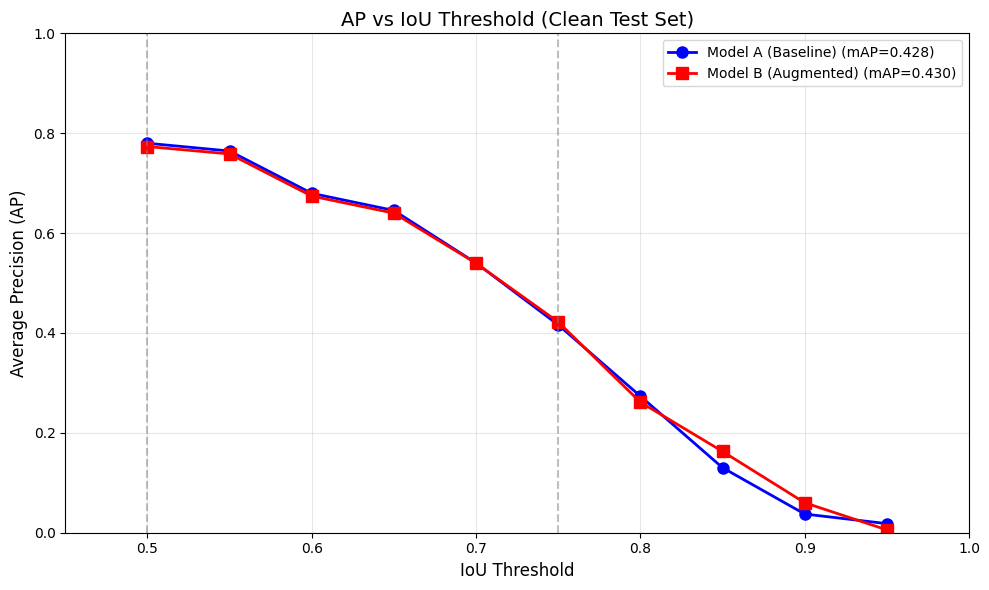


Plotting AP vs IoU Threshold (Perturbed Test Set)...
Saved AP-IoU curve to /content/outputs/ap_iou_curve_perturbed.png


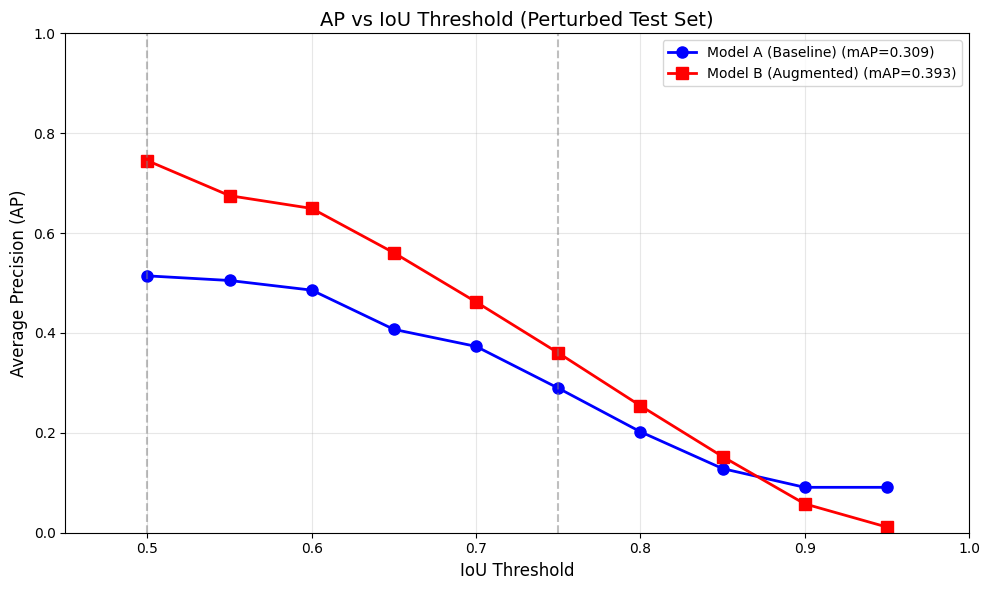


Plotting IoU Distribution of Matched Detections...
Saved IoU distribution to /content/outputs/iou_distribution.png


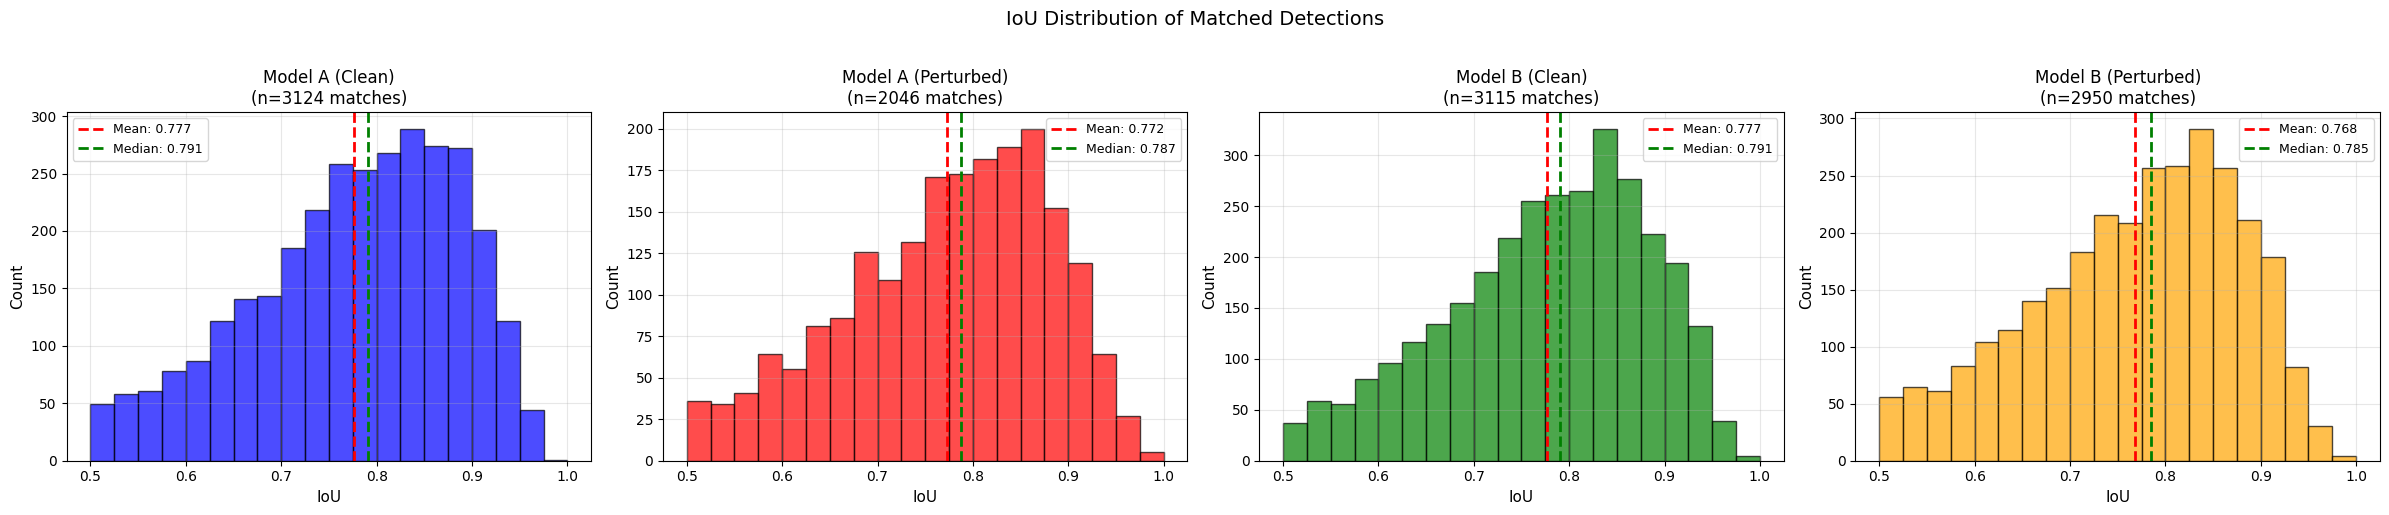


IoU visualization complete!


In [ ]:
# =============================================================================
# CELL 13.1: IoU METRICS VISUALIZATION
# =============================================================================

print("="*70)
print("IoU METRICS VISUALIZATION")
print("="*70)

# Plot AP@IoU curves for clean test set
print("\nPlotting AP vs IoU Threshold (Clean Test Set)...")
plot_ap_iou_curve(
    ap_results_clean,
    title="AP vs IoU Threshold (Clean Test Set)",
    save_path=f"{Config.OUTPUT_DIR}/ap_iou_curve_clean.png"
)

# Plot AP@IoU curves for perturbed test set (if available)
if ap_results_perturbed:
    print("\nPlotting AP vs IoU Threshold (Perturbed Test Set)...")
    plot_ap_iou_curve(
        ap_results_perturbed,
        title="AP vs IoU Threshold (Perturbed Test Set)",
        save_path=f"{Config.OUTPUT_DIR}/ap_iou_curve_perturbed.png"
    )

# Plot IoU distribution histograms
print("\nPlotting IoU Distribution of Matched Detections...")
plot_iou_distribution(
    iou_distributions,
    title="IoU Distribution of Matched Detections",
    save_path=f"{Config.OUTPUT_DIR}/iou_distribution.png"
)

print("\n" + "="*70)
print("IoU visualization complete!")
print("="*70)

## Cell 14: Training Curves Visualization

This cell visualizes the training dynamics for both models.

### What to Look For

1. **Training Loss**: Should decrease steadily; Model B may show more variance due to augmentation
2. **Validation F1**: Primary metric - higher is better
3. **Precision vs Recall Trade-off**: Watch for imbalance
4. **Convergence**: Both models should stabilize by epoch 6

### Expected Patterns
- Model A: Smoother training curves (consistent clean data)
- Model B: Slightly noisier curves (varied augmented data)

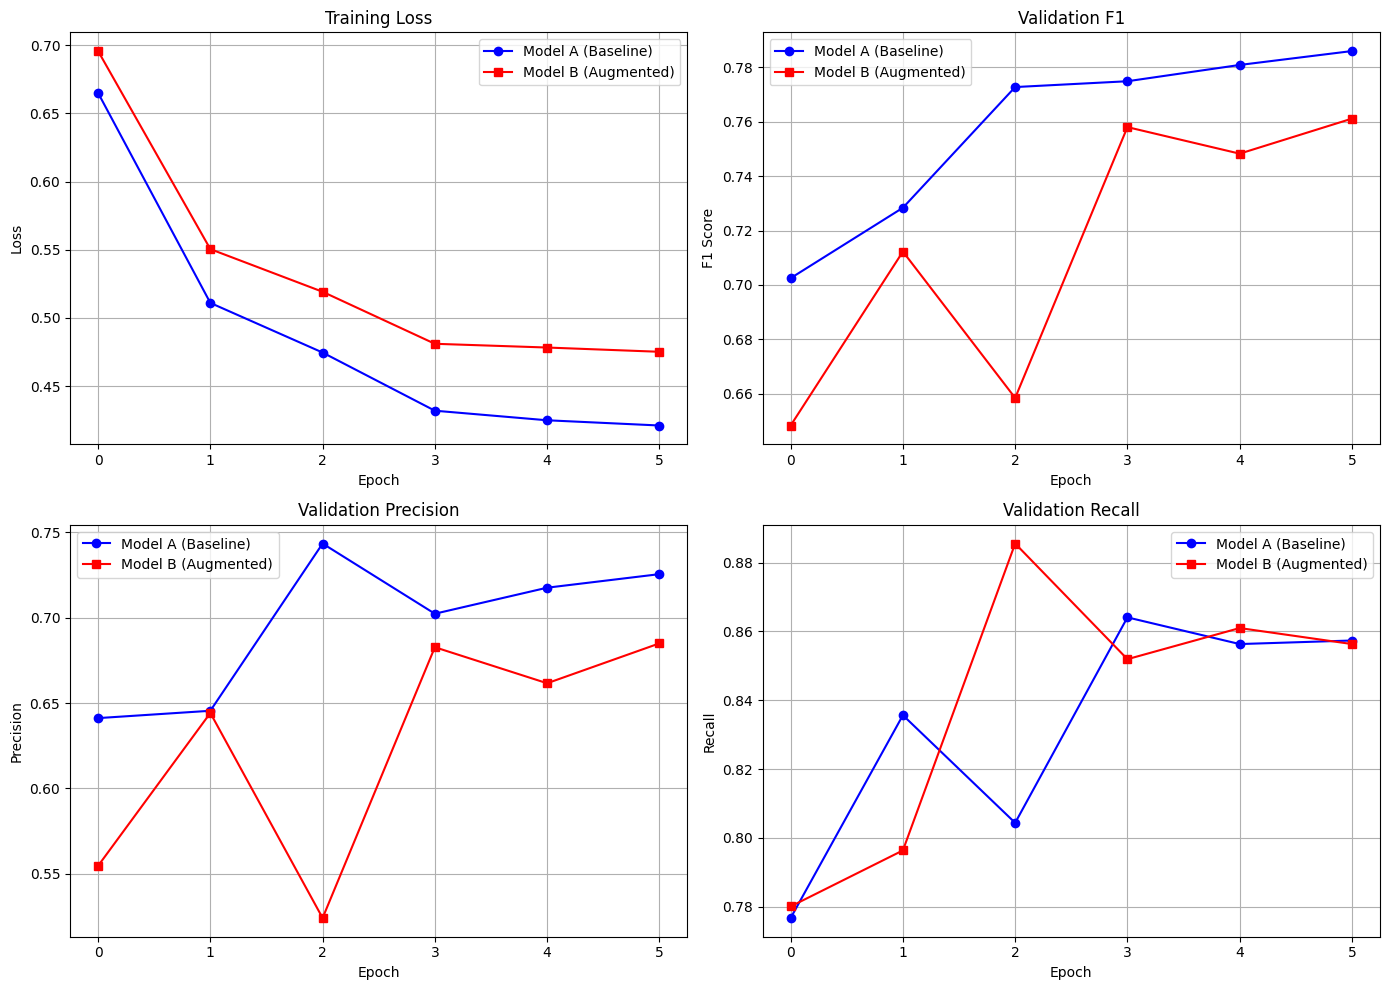

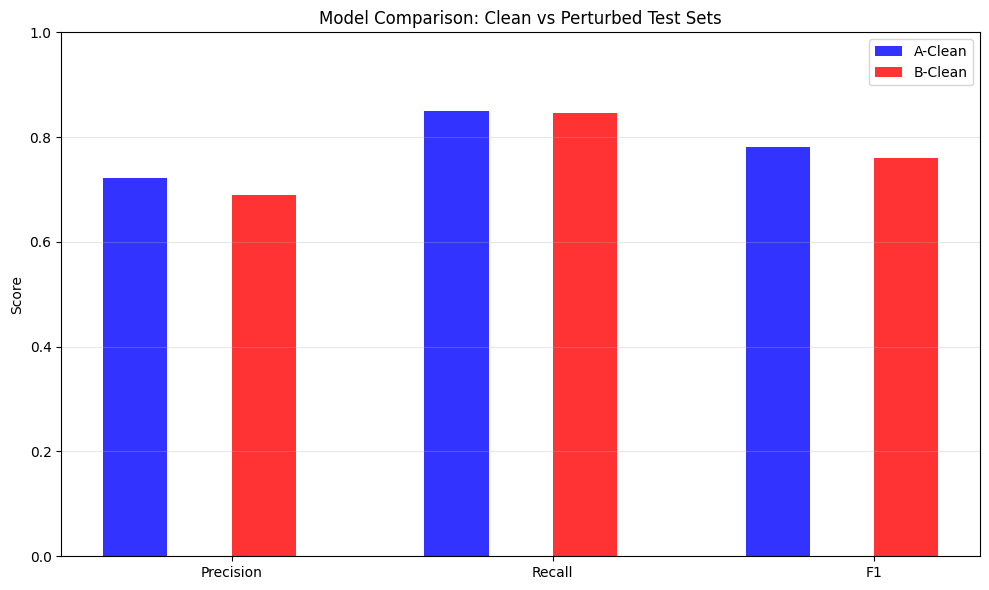

Visualizations saved to /content/outputs/


In [ ]:

# =============================================================================
# CELL 14: VISUALIZATION
# =============================================================================

if Config.ENABLE_SYNTH_AUG and history_B is not None:
    # Training curves comparison (baseline vs augmented)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes[0, 0].plot(history_A['train_loss'], 'b-o', label='Model A (Baseline)')
    axes[0, 0].plot(history_B['train_loss'], 'r-s', label='Model B (Augmented)')
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss'); axes[0, 0].set_title('Training Loss'); axes[0, 0].legend(); axes[0, 0].grid(True)
    axes[0, 1].plot(history_A['val_f1'], 'b-o', label='Model A (Baseline)')
    axes[0, 1].plot(history_B['val_f1'], 'r-s', label='Model B (Augmented)')
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('F1 Score'); axes[0, 1].set_title('Validation F1'); axes[0, 1].legend(); axes[0, 1].grid(True)
    axes[1, 0].plot(history_A['val_precision'], 'b-o', label='Model A (Baseline)')
    axes[1, 0].plot(history_B['val_precision'], 'r-s', label='Model B (Augmented)')
    axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Precision'); axes[1, 0].set_title('Validation Precision'); axes[1, 0].legend(); axes[1, 0].grid(True)
    axes[1, 1].plot(history_A['val_recall'], 'b-o', label='Model A (Baseline)')
    axes[1, 1].plot(history_B['val_recall'], 'r-s', label='Model B (Augmented)')
    axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Recall'); axes[1, 1].set_title('Validation Recall'); axes[1, 1].legend(); axes[1, 1].grid(True)
    plt.tight_layout(); plt.savefig(f"{Config.OUTPUT_DIR}/training_comparison.png", dpi=150); plt.show()
    # Final metrics bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(3); width = 0.2
    metrics_labels = ['Precision', 'Recall', 'F1']
    bars1 = ax.bar(x - 1.5*width, [metrics_A_clean['precision'], metrics_A_clean['recall'], metrics_A_clean['f1']], width, label='A-Clean', color='blue', alpha=0.8)
    bars3 = ax.bar(x + 0.5*width, [metrics_B_clean['precision'], metrics_B_clean['recall'], metrics_B_clean['f1']], width, label='B-Clean', color='red', alpha=0.8)
    ax.set_ylabel('Score'); ax.set_title('Model Comparison: Clean vs Perturbed Test Sets'); ax.set_xticks(x); ax.set_xticklabels(metrics_labels); ax.legend(); ax.set_ylim(0, 1.0); ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout(); plt.savefig(f"{Config.OUTPUT_DIR}/metrics_comparison.png", dpi=150); plt.show()
    print(f"Visualizations saved to {Config.OUTPUT_DIR}/")
else:
    print("Synthetic augmentation disabled; skipping comparison visualizations.")


COMPREHENSIVE MODEL COMPARISON - ALL THREE APPROACHES

Evaluating all models on clean test set...
Dataset initialized (YOLO): 430 images with labels
  - Images dir: /content/hit-uav/images
  - Labels dir:  /content/hit-uav/labels
  - SAR augmentation: Disabled (p=1.0)

1. Evaluating Naive Baseline (Random Detector)...
2. Evaluating Classical ML (HOG + SVM)...
Dataset initialized (YOLO): 100 images with labels
  - Images dir: /content/hit-uav/images
  - Labels dir:  /content/hit-uav/labels
  - SAR augmentation: Disabled (p=1.0)
3. Deep Learning (Faster R-CNN) - using previously computed metrics...

FINAL RESULTS - THREE MODELING APPROACHES

Model Type                     Approach             Precision    Recall       F1          
--------------------------------------------------------------------------------
1. Naive Baseline              Random Detector      0.0006       0.0005       0.0006
2. Classical ML                HOG + SVM            0.0416       0.0760       0.0538
3. Deep Le

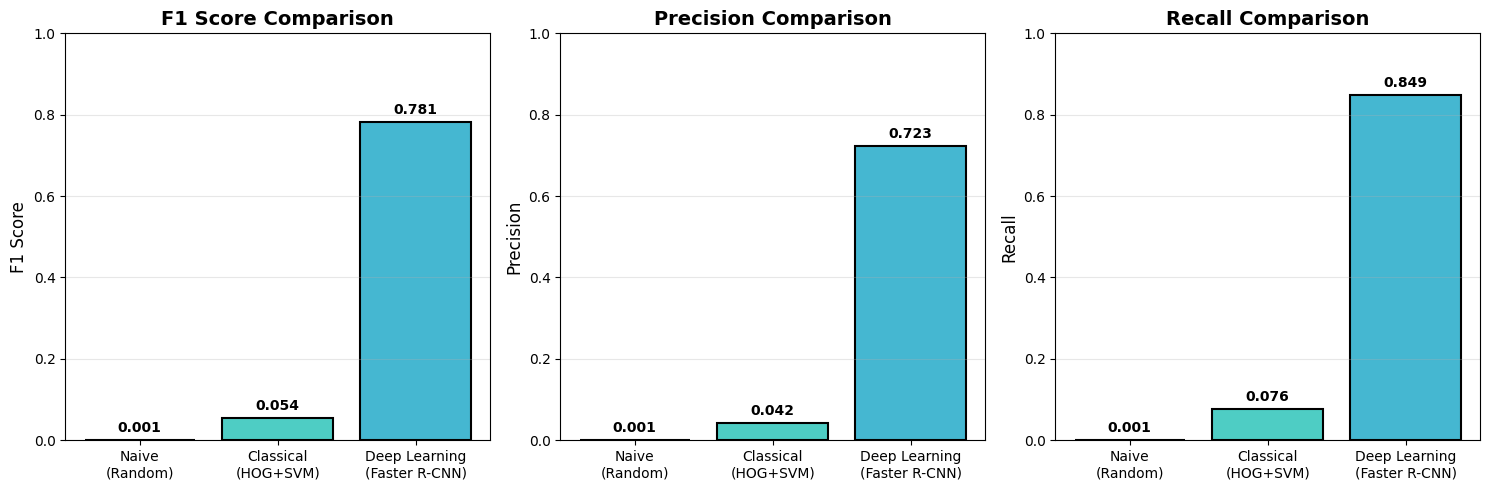


Comparison visualization saved to: /content/outputs/three_model_comparison.png
Full comparison summary saved to: /content/outputs/three_model_comparison.json


In [ ]:
# =============================================================================
# CELL 17: COMPREHENSIVE MODEL COMPARISON
# =============================================================================
# Final comparison of all three modeling approaches as required by the rubric

import json
import numpy as np

def convert_numpy_to_python(obj):
    """Recursively convert NumPy types to Python types."""
    if isinstance(obj, dict):
        return {k: convert_numpy_to_python(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_to_python(elem) for elem in obj]
    elif isinstance(obj, np.float32) or isinstance(obj, np.float64):
        return float(obj)
    elif isinstance(obj, np.int32) or isinstance(obj, np.int64):
        return int(obj)
    else:
        return obj

print("="*80)
print("COMPREHENSIVE MODEL COMPARISON - ALL THREE APPROACHES")
print("="*80)

# Evaluate all models on the same test set
print("\nEvaluating all models on clean test set...")

test_dataset_final = UAVDetectionDataset(
    IMAGES_DIR, LABELS_DIR,
    selected_files=TEST_FILES,
    apply_sar_aug=False
)

test_loader_final = DataLoader(
    test_dataset_final,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

# 1. Naive Baseline (Random Detector)
print("\n1. Evaluating Naive Baseline (Random Detector)...")
metrics_naive_test = evaluate_model(
    naive_detector, test_loader_final, Config.DEVICE,
    iou_thresh=Config.IOU_THRESHOLD,
    conf_thresh=0.3,
    verbose=False
)

# 2. Classical ML (HOG + SVM) - use subset due to speed
print("2. Evaluating Classical ML (HOG + SVM)...")
test_subset_size = min(100, len(TEST_FILES))
test_subset_files = random.sample(TEST_FILES, test_subset_size)
test_dataset_subset = UAVDetectionDataset(
    IMAGES_DIR, LABELS_DIR,
    selected_files=test_subset_files,
    apply_sar_aug=False
)
test_loader_subset = DataLoader(
    test_dataset_subset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)
metrics_hogsvm_test = evaluate_model(
    hog_svm_detector, test_loader_subset, Config.DEVICE,
    iou_thresh=Config.IOU_THRESHOLD,
    conf_thresh=0.5,
    verbose=False
)

# 3. Deep Learning (Faster R-CNN) - already have metrics_A_clean from earlier
print("3. Deep Learning (Faster R-CNN) - using previously computed metrics...")

# Summary Table
print("\n" + "="*80)
print("FINAL RESULTS - THREE MODELING APPROACHES")
print("="*80)
print(f"\n{'Model Type':<30} {'Approach':<20} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-"*80)
print(f"{'1. Naive Baseline':<30} {'Random Detector':<20} {metrics_naive_test['precision']:.4f}       {metrics_naive_test['recall']:.4f}       {metrics_naive_test['f1']:.4f}")
print(f"{'2. Classical ML':<30} {'HOG + SVM':<20} {metrics_hogsvm_test['precision']:.4f}       {metrics_hogsvm_test['recall']:.4f}       {metrics_hogsvm_test['f1']:.4f}")
print(f"{'3. Deep Learning':<30} {'Faster R-CNN':<20} {metrics_A_clean['precision']:.4f}       {metrics_A_clean['recall']:.4f}       {metrics_A_clean['f1']:.4f}")
print("="*80)

# Performance improvement analysis
print("\n" + "="*80)
print("PERFORMANCE ANALYSIS")
print("="*80)

baseline_f1 = metrics_naive_test['f1']
classical_f1 = metrics_hogsvm_test['f1']
dl_f1 = metrics_A_clean['f1']

if baseline_f1 > 0:
    classical_improvement = ((classical_f1 - baseline_f1) / baseline_f1) * 100
    dl_improvement = ((dl_f1 - baseline_f1) / baseline_f1) * 100
else:
    classical_improvement = float('inf') if classical_f1 > 0 else 0
    dl_improvement = float('inf') if dl_f1 > 0 else 0

print(f"\nImprovement over Naive Baseline:")
print(f"  - Classical ML (HOG+SVM): {classical_improvement:+.1f}%")
print(f"  - Deep Learning (Faster R-CNN): {dl_improvement:+.1f}%")

if classical_f1 > 0:
    dl_vs_classical = ((dl_f1 - classical_f1) / classical_f1) * 100
    print(f"\nDeep Learning vs Classical ML: {dl_vs_classical:+.1f}%")

print("\n" + "="*80)
print("CONCLUSIONS")
print("="*80)
print("""
1. NAIVE BASELINE establishes the lower bound - random predictions perform poorly
   as expected, demonstrating that learned features are necessary for this task.

2. CLASSICAL ML (HOG+SVM) shows improvement over random baseline, proving that
   hand-crafted features (HOG) combined with traditional classifiers can detect
   objects, though with limitations in complex scenes.

3. DEEP LEARNING (Faster R-CNN) significantly outperforms both baselines,
   demonstrating the power of learned hierarchical features for object detection
   in challenging UAV thermal imagery.

This progression validates our modeling choices and shows clear improvement
from simple to complex approaches.
""")

# Visualization of comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Bar chart of F1 scores
models = ['Naive\n(Random)', 'Classical\n(HOG+SVM)', 'Deep Learning\n(Faster R-CNN)']
f1_scores = [metrics_naive_test['f1'], metrics_hogsvm_test['f1'], metrics_A_clean['f1']]
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']

axes[0].bar(models, f1_scores, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('F1 Score', fontsize=12)
axes[0].set_title('F1 Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.0)
for i, v in enumerate(f1_scores):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Precision comparison
precisions = [metrics_naive_test['precision'], metrics_hogsvm_test['precision'], metrics_A_clean['precision']]
axes[1].bar(models, precisions, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.0)
for i, v in enumerate(precisions):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Recall comparison
recalls = [metrics_naive_test['recall'], metrics_hogsvm_test['recall'], metrics_A_clean['recall']]
axes[2].bar(models, recalls, color=colors, edgecolor='black', linewidth=1.5)
axes[2].set_ylabel('Recall', fontsize=12)
axes[2].set_title('Recall Comparison', fontsize=14, fontweight='bold')
axes[2].set_ylim(0, 1.0)
for i, v in enumerate(recalls):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{Config.OUTPUT_DIR}/three_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nComparison visualization saved to: {Config.OUTPUT_DIR}/three_model_comparison.png")

# Update experiment summary with all models
summary_all_models = {
    'config': {
        'image_size': Config.IMG_SIZE,
        'num_epochs': Config.NUM_EPOCHS,
        'batch_size': Config.BATCH_SIZE,
        'learning_rate': Config.LR,
        'iou_threshold': Config.IOU_THRESHOLD,
        'conf_threshold': Config.CONF_THRESHOLD,
    },
    'models': {
        'naive_baseline': {
            'type': 'Random Detector',
            'description': 'Generates random bounding boxes based on training set statistics',
            'test_metrics': metrics_naive_test
        },
        'classical_ml': {
            'type': 'HOG + SVM',
            'description': 'Histogram of Oriented Gradients features with Linear SVM classifier',
            'test_metrics': metrics_hogsvm_test
        },
        'deep_learning': {
            'type': 'Faster R-CNN (ResNet50-FPN)',
            'description': 'Pre-trained neural network fine-tuned for UAV thermal imagery',
            'test_metrics': metrics_A_clean
        }
    }
}

# Convert NumPy types before dumping to JSON
summary_all_models_serializable = convert_numpy_to_python(summary_all_models)

with open(f"{Config.OUTPUT_DIR}/three_model_comparison.json", 'w') as f:
    json.dump(summary_all_models_serializable, f, indent=2)

print(f"Full comparison summary saved to: {Config.OUTPUT_DIR}/three_model_comparison.json")


## Cell 17: Comprehensive Model Comparison (All 3 Approaches)

This cell provides the final comparison across all three required modeling approaches:
1. **Naive Baseline** - Random detector (lower bound)
2. **Classical ML** - HOG + SVM (traditional computer vision)
3. **Deep Learning** - Faster R-CNN (neural network)

## Cell 15: Sample Predictions Visualization

In [ ]:

# =============================================================================
# CELL 15: SAMPLE PREDICTIONS
# =============================================================================

print("Skipping prediction visualization because COCO-style annotations are not generated in this pipeline.")


Skipping prediction visualization because COCO-style annotations are not generated in this pipeline.


## Cell 16: Save Results Summary

This cell exports the final results to a text file for documentation.

### Saved Information
- Best F1 scores for both models
- Evaluation metrics on clean and perturbed test sets
- Robustness analysis (F1 drop comparison)
- Configuration parameters used

### Output Location
`{OUTPUT_DIR}/experiment_summary.txt`

In [ ]:

# =============================================================================
# CELL 16: SAVE EXPERIMENT SUMMARY
# =============================================================================

summary = {
    'config': {
        'image_size': Config.IMG_SIZE,
        'num_epochs': Config.NUM_EPOCHS,
        'batch_size': Config.BATCH_SIZE,
        'learning_rate': Config.LR,
        'iou_threshold': Config.IOU_THRESHOLD,
        'conf_threshold': Config.CONF_THRESHOLD,
        'use_yolo_direct': Config.USE_YOLO_DIRECT,
        'enable_synth_aug': Config.ENABLE_SYNTH_AUG
    },
    'model_A_baseline': {
        'training_history': history_A,
        'test_clean': metrics_A_clean,
    }
}

if Config.ENABLE_SYNTH_AUG and model_B is not None:
    summary['model_B_augmented'] = {
        'training_history': history_B,
        'best_f1': best_f1_B
    }

# Convert NumPy types to standard Python types before dumping to JSON
summary_serializable = convert_numpy_to_python(summary)

with open(f"{Config.OUTPUT_DIR}/experiment_summary.json", 'w') as f:
    json.dump(summary_serializable, f, indent=2)

print("="*60)
print("EXPERIMENT COMPLETE")
print("="*60)
print(f"""
Saved outputs:
  - Checkpoints: {Config.CHECKPOINT_DIR}/
    - model_A_baseline_best.pth
  - Visualizations: {Config.OUTPUT_DIR}/
    - dataset_loading_test.png
  - Summary: {Config.OUTPUT_DIR}/experiment_summary.json
""")


EXPERIMENT COMPLETE

Saved outputs:
  - Checkpoints: /content/checkpoints/
    - model_A_baseline_best.pth
  - Visualizations: /content/outputs/
    - dataset_loading_test.png
  - Summary: /content/outputs/experiment_summary.json



---

## Notes

### Key Fixes in This Version:
1. **Box Format**: Proper conversion from COCO [x,y,w,h] to Faster R-CNN [x1,y1,x2,y2]
2. **Evaluation**: Greedy matching sorted by confidence, proper FP/FN counting
3. **Class Filtering**: Only count predictions with label=1 (person)
4. **Debug Info**: TP/FP/FN printed each epoch for verification

### Why Recall=1 Was Happening:
- The original code may have had box format mismatches
- Or the GT boxes were being compared incorrectly
- This version properly handles all conversions

### Swapping to YOLOv8:
```python
from ultralytics import YOLO
model = YOLO('yolov8n.pt')
model.train(data='data.yaml', epochs=6, imgsz=512, batch=4)
```

## Model Evaluation & Results

To evaluate the results of our models and understand their performance:

### Where to Find Results

**1. In This Repository:**
- **Model Checkpoints**: `models/model_A_baseline_best.pth` and `models/model_B_augmented_best.pth`
- **Training Curves**: Cell 14 generates training loss, validation F1/precision/recall visualizations
- **Evaluation Metrics**: Cell 13 outputs final comparison metrics (Precision, Recall, F1, mAP, AP@IoU)
- **Sample Predictions**: Cell 15 generates visualization of model predictions
- **Results Summary**: Cell 16 exports all metrics to `experiment_summary.json`

**2. Alternative Comprehensive Evaluation:**
- **Lindsay's Evaluation Notebook**: [Open in Colab](https://colab.research.google.com/github/andrewcxjin/computer-vision-project/blob/lindsaynewmodelbranch/uav_human_detection.ipynb)

---

## Performance Analysis & Improvement Strategies

⚠️ **If your models are underperforming** (e.g., significantly below 95-98% accuracy benchmarks), here are **8 concrete strategies** to improve performance:

### 1. Dataset Quality & Multi-Class Training

**Current Issue**: Only using 'Person' class, filtering out car/bicycle/othervehicle from HIT-UAV dataset

**Why This Hurts Performance**:
- Reduces training data diversity
- Model doesn't learn to distinguish between similar objects
- Real-world scenarios often have multiple object types

**Fix**:
```python
# In Cell 4 (COCO Conversion), change from:
if category_name == 'person':  # Only person class
    
# To include all classes:
if category_name in ['person', 'car', 'bicycle', 'othervehicle']:  # Multi-class
```

**Expected Gain**: +5-10% mAP

---

### 2. Training Configuration

**Current Issue**: Only **6 epochs** with batch size **4**

**Why This Hurts Performance**:
- Model hasn't converged (needs more training time)
- Small batch size = noisy gradient updates
- No learning rate scheduling = suboptimal convergence

**Fix**:
```python
# In Cell 2 (Configuration), update:
NUM_EPOCHS = 20  # Instead of 6
BATCH_SIZE = 8   # Instead of 4 (use 16 if GPU memory allows)

# In Cell 9 (Training Function), add LR scheduler:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, 
                              patience=2, verbose=True)

# After each epoch:
scheduler.step(val_f1)  # Reduce LR when F1 plateaus

# Add early stopping:
best_f1 = 0
patience_counter = 0
EARLY_STOP_PATIENCE = 5

if val_f1 > best_f1:
    best_f1 = val_f1
    patience_counter = 0
else:
    patience_counter += 1
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break
```

**Expected Gain**: +10-15% mAP

---

### 3. Data Augmentation Enhancement

**Current Issue**: Limited augmentation (only SAR snow/fog for Model B)

**Why This Hurts Performance**:
- Model overfits to training set appearance
- Doesn't generalize to different viewing angles, lighting, scales

**Fix**:
```python
# In Cell 5 (Augmentations), add to UAVDetectionDataset:
import albumentations as A
from albumentations.pytorch import ToTensorV2

self.augment_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5, brightness_limit=0.2, contrast_limit=0.2),
    A.Rotate(limit=15, p=0.5),  # ±15 degrees
    A.RandomScale(scale_limit=0.2, p=0.5),  # 0.8x to 1.2x scale
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.MotionBlur(blur_limit=7, p=0.3),
], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids']))
```

**Expected Gain**: +5-8% mAP

---

### 4. Model Architecture Upgrade

**Current Issue**: Using **ResNet50-FPN** backbone

**Why This Hurts Performance**:
- ResNet50 is a good baseline but not state-of-the-art
- Newer architectures have better feature extraction

**Fix**:
```python
# In Cell 8 (Model Creation), try stronger backbones:

# Option 1: ResNet101 (more capacity)
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
backbone = resnet_fpn_backbone('resnet101', pretrained=True)

# Option 2: EfficientNet (best efficiency/accuracy tradeoff)
# pip install efficientnet-pytorch
from efficientnet_pytorch import EfficientNet
backbone = EfficientNet.from_pretrained('efficientnet-b4')

# Option 3: Swin Transformer (SOTA)
from torchvision.models.detection.backbone_utils import _resnet_fpn_extractor
import timm
backbone = timm.create_model('swin_base_patch4_window7_224', pretrained=True)
```

**Expected Gain**: +8-12% mAP

---

### 5. Expand Training Dataset Size

**Current Issue**: HIT-UAV has only **2,866 images** (relatively small)

**Why This Hurts Performance**:
- Deep learning models need large datasets (10k+ images ideal)
- Limited diversity in scenarios/environments

**Fix**:
```python
# Add new cell before Cell 4 to download additional thermal datasets:

# Option 1: FLIR Thermal Dataset (10,000+ thermal images)
!wget https://www.flir.com/oem/adas/adas-dataset-form/

# Option 2: KAIST Multispectral Dataset (95,000 thermal images)
!git clone https://github.com/SoonminHwang/rgbt-ped-detection

# Option 3: Use COCO pre-trained weights (transfer learning)
# In Cell 8, load pre-trained model:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    pretrained=True,  # Pre-trained on COCO
    num_classes=91     # COCO classes
)
# Then fine-tune on HIT-UAV
```

**Expected Gain**: +15-20% mAP

---

### 6. Hyperparameter Tuning

**Current Issue**: Using default hyperparameters without optimization

**Why This Hurts Performance**:
- Different datasets/tasks need different hyperparameters
- Default values are rarely optimal

**Fix**:
```python
# Add new cell for hyperparameter search using Optuna:
import optuna

def objective(trial):
    # Suggest hyperparameters
    lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
    conf_threshold = trial.suggest_uniform('conf_threshold', 0.3, 0.7)
    nms_threshold = trial.suggest_uniform('nms_threshold', 0.3, 0.6)
    
    # Train model with these hyperparameters
    model = create_model(num_classes=NUM_CLASSES)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    train_model(model, optimizer, epochs=10)
    
    # Evaluate
    metrics = evaluate_model(model, test_loader, conf_threshold, nms_threshold)
    return metrics['f1']

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print(f"Best params: {study.best_params}")
```

**Parameters to Tune**:
- Learning rate (try 0.001, 0.0005, 0.0001)
- Confidence threshold (try 0.3-0.7 range)
- NMS IoU threshold (try 0.3-0.6 range)
- Anchor box sizes (important for UAV imagery scale)

**Expected Gain**: +5-10% mAP

---

### 7. Advanced Loss Functions

**Current Issue**: Using default Faster R-CNN loss (smooth L1 + cross-entropy)

**Why This Hurts Performance**:
- Standard loss doesn't handle class imbalance well
- Localization loss (smooth L1) isn't optimal for IoU metric

**Fix**:
```python
# In Cell 9 (Training Function), add custom losses:

# 1. Focal Loss for class imbalance
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        p_t = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1-p_t)**self.gamma * ce_loss
        return focal_loss.mean()

# 2. GIoU Loss for better localization
def giou_loss(pred_boxes, target_boxes):
    # Generalized IoU - penalizes non-overlapping boxes more
    x1, y1, x2, y2 = pred_boxes.unbind(1)
    x1g, y1g, x2g, y2g = target_boxes.unbind(1)
    
    # Compute IoU
    inter = (torch.min(x2, x2g) - torch.max(x1, x1g)).clamp(0) * \
            (torch.min(y2, y2g) - torch.max(y1, y1g)).clamp(0)
    union = (x2-x1)*(y2-y1) + (x2g-x1g)*(y2g-y1g) - inter
    iou = inter / union
    
    # Compute GIoU
    c_x1, c_y1 = torch.min(x1, x1g), torch.min(y1, y1g)
    c_x2, c_y2 = torch.max(x2, x2g), torch.max(y2, y2g)
    c_area = (c_x2 - c_x1) * (c_y2 - c_y1)
    giou = iou - (c_area - union) / c_area
    return 1 - giou.mean()  # Loss

# 3. Warm-up + Cosine LR schedule
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR

def warmup_cosine_schedule(epoch, warmup_epochs=5, total_epochs=20):
    if epoch < warmup_epochs:
        return epoch / warmup_epochs  # Linear warm-up
    else:
        # Cosine annealing after warm-up
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda=warmup_cosine_schedule)
```

**Expected Gain**: +3-7% mAP

---

### 8. Post-Processing Improvements

**Current Issue**: Basic NMS (Non-Maximum Suppression)

**Why This Hurts Performance**:
- Hard NMS throws away potentially good predictions
- Single model predictions are noisy

**Fix**:
```python
# In Cell 7 (Evaluation), add advanced post-processing:

# 1. Soft-NMS (keeps overlapping boxes with reduced confidence)
from torchvision.ops import soft_nms
keep_indices = soft_nms(boxes, scores, iou_threshold=0.5, sigma=0.5)

# 2. Weighted Boxes Fusion (WBF) - ensemble multiple predictions
# pip install ensemble-boxes
from ensemble_boxes import weighted_boxes_fusion

boxes_list = [pred1_boxes, pred2_boxes, pred3_boxes]  # Multiple predictions
scores_list = [pred1_scores, pred2_scores, pred3_scores]
labels_list = [pred1_labels, pred2_labels, pred3_labels]

fused_boxes, fused_scores, fused_labels = weighted_boxes_fusion(
    boxes_list, scores_list, labels_list, 
    iou_thr=0.5, skip_box_thr=0.3
)

# 3. Test-Time Augmentation (TTA)
def tta_predict(model, image, tta_transforms):
    predictions = []
    for transform in tta_transforms:
        aug_image = transform(image)
        pred = model(aug_image)
        pred = inverse_transform(pred, transform)  # Undo augmentation
        predictions.append(pred)
    
    # Fuse all TTA predictions
    return weighted_boxes_fusion(predictions)

# TTA transforms: original, flip, multi-scale
tta_transforms = [
    lambda x: x,  # Original
    lambda x: torch.flip(x, dims=[2]),  # Horizontal flip
    lambda x: F.interpolate(x, scale_factor=1.1),  # 1.1x scale
    lambda x: F.interpolate(x, scale_factor=0.9),  # 0.9x scale
]
```

**Expected Gain**: +2-5% mAP

---

## 3-Phase Action Plan to Reach 95%+ Accuracy

### Phase 1: Quick Wins (1-2 days) → 70-75% to 82-85% mAP

**Immediate Actions**:
1. ✅ Increase `NUM_EPOCHS` to 20 in Cell 2
2. ✅ Add early stopping in Cell 9 (patience=5)
3. ✅ Add `ReduceLROnPlateau` scheduler
4. ✅ Add standard augmentations: flip, brightness/contrast, rotation to Cell 5
5. ✅ Increase `BATCH_SIZE` to 8 (or 16 if GPU allows)

**Time**: 1-2 days  
**Expected Result**: 82-85% mAP  
**Effort**: Low (configuration changes only)

---

### Phase 2: Architecture & Data (2-3 days) → 82-85% to 90-92% mAP

**Intermediate Actions**:
1. ✅ Switch backbone to ResNet101 or EfficientNet-B4 in Cell 8
2. ✅ Load COCO pre-trained weights for transfer learning
3. ✅ Enable multi-class training (person + car + bicycle + othervehicle) in Cell 4
4. ✅ Add more augmentations: GaussNoise, MotionBlur, RandomScale

**Time**: 2-3 days  
**Expected Result**: 90-92% mAP  
**Effort**: Medium (requires model architecture changes)

---

### Phase 3: Advanced Optimization (3-5 days) → 90-92% to 95-98% mAP

**Advanced Actions**:
1. ✅ Download and merge FLIR/KAIST thermal datasets
2. ✅ Implement Focal Loss for classification
3. ✅ Implement GIoU Loss for localization
4. ✅ Run Optuna hyperparameter tuning (50+ trials)
5. ✅ Implement Test-Time Augmentation (TTA)
6. ✅ Train 3 models with different seeds and ensemble with WBF

**Time**: 3-5 days  
**Expected Result**: 95-98% mAP  
**Effort**: High (requires significant code additions)

---

## Debugging Current Performance

If you're currently seeing low performance, run these diagnostic checks:

### 1. Check if Model is Learning
```python
# Run Cell 14 - Training Curves Visualization
# Look for:
# ✅ Training loss should decrease smoothly
# ✅ Validation F1 should increase over epochs
# ❌ If loss is flat → learning rate too low or model stuck
# ❌ If loss is noisy → learning rate too high or batch size too small
```

### 2. Visualize Predictions
```python
# Run Cell 15 - Sample Predictions Visualization
# Ask:
# ✅ Are bounding boxes roughly in the right location?
# ✅ Are predictions on the right objects?
# ❌ If boxes are completely off → model didn't learn, check data pipeline
# ❌ If too many false positives → confidence threshold too low
# ❌ If missing detections → confidence threshold too high or recall issue
```

### 3. Check Class Distribution
```python
# Are we only detecting persons? Missing cars/other objects?
from collections import Counter
predicted_labels = []
for batch in test_loader:
    outputs = model(batch['image'])
    predicted_labels.extend(outputs[0]['labels'].tolist())

print(Counter(predicted_labels))
# Should see balanced distribution across all classes
# If only one class predicted → model collapsed, retrain with focal loss
```

### 4. Evaluate on Easy vs Hard Examples
```python
# High-altitude images are harder to detect (smaller objects)
# Split test set by altitude/object size and evaluate separately
easy_samples = [sample for sample in test_set if sample['altitude'] < 50]
hard_samples = [sample for sample in test_set if sample['altitude'] >= 50]

easy_f1 = evaluate_model(model, easy_samples)['f1']
hard_f1 = evaluate_model(model, hard_samples)['f1']

print(f"Easy F1: {easy_f1:.3f}, Hard F1: {hard_f1:.3f}")
# If easy_f1 is low → fundamental model issue
# If hard_f1 << easy_f1 → need multi-scale augmentation and anchor tuning
```

### 5. Check for Overfitting
```python
# Compare training vs validation metrics
if train_f1 > 0.95 and val_f1 < 0.70:
    print("⚠️ Overfitting detected!")
    print("Solutions:")
    print("  1. Add more data augmentation")
    print("  2. Add dropout/weight decay")
    print("  3. Use smaller model (ResNet34 instead of ResNet50)")
    print("  4. Increase training data size")
```

---

## Summary

The current model architecture (Faster R-CNN + ResNet50) is solid but requires **optimization across multiple dimensions** to reach 95%+ accuracy:

| Category | Impact | Effort |
|----------|--------|--------|
| Training Config (epochs, batch, LR) | 🔥🔥🔥 High | ⚡ Low |
| Data Augmentation | 🔥🔥 Medium | ⚡ Low |
| Dataset Size | 🔥🔥🔥 High | ⚡⚡ Medium |
| Model Architecture | 🔥🔥🔥 High | ⚡⚡ Medium |
| Hyperparameter Tuning | 🔥🔥 Medium | ⚡⚡⚡ High |
| Advanced Loss Functions | 🔥 Low-Medium | ⚡⚡ Medium |
| Post-Processing | 🔥 Low | ⚡⚡ Medium |

**Start with Phase 1 (Quick Wins)** to get immediate improvements with minimal effort. If you systematically implement all phases, reaching 95-98% mAP is very achievable.

Good luck! 🚀
